# **Лабораторная работа 1. Регрессия и метод главных компонент**

## Введение
### Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.

### Задачи
1.   Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).
2.   Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.
3.   Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).
4.   Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).
5.   Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
6.   Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.
7.   Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

# **Описание датасета**
В работе используется датасет California Housing Prices.
Датасет содержит 20 640 наблюдений и 10 признаков, из которых 9 - числовые, 1 - категориальный.
Названия признаков:
1. longitude - долгота
2. latitude - широта
3. housing_median_age - медианный возраст домов
4. total_rooms - общее число комнат
5. total_bedrooms - общее число спален
6. population - население
7. households - домохозяйства
8. median_income - медианный доход
9. median_house_value - медианная стоимость дома
10. ocean_proximity - близость к океану (категориальный признак)

Категориальный признак ocean_proximity принимает пять значений: <1H OCEAN, INLAND, NEAR OCEAN, NEAR BAY и ISLAND.



In [132]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

os.makedirs('graphs', exist_ok=True)

FILE_NAME = 'housing.csv'

encodings = [
    'utf-8',
    'utf-8-sig',
    'cp1251',
    'latin1'
]

df = None

for encoding in encodings:
    try:
        df = pd.read_csv(FILE_NAME, encoding=encoding)
        print(f'Файл успешно прочитан в кодировке: {encoding}')
        break

    except UnicodeDecodeError:
        continue

if df is None:
    print('Не удалось определить кодировку файла.')
    print('Попробуйте сохранить CSV в формате UTF-8.')
    exit()


print('=' * 60)
print('ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ')
print('=' * 60)

print('\nРазмер датасета:')
print(df.shape)

print('\nПервые 5 строк:')
print(df.head())

print('\nИнформация о датасете:')
df.info()

print('\nНазвания признаков:')
for i, column in enumerate(df.columns, 1):
    print(f'{i}. {column}')

print('\nПропущенные значения:')
print(df.isnull().sum())

print('\nКоличество дубликатов:')
print(df.duplicated().sum())

print('\nОписательная статистика:')
print(df.describe())



Файл успешно прочитан в кодировке: utf-8
ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ

Размер датасета:
(20640, 10)

Первые 5 строк:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88               41.00       880.00          129.00   
1    -122.22     37.86               21.00      7099.00         1106.00   
2    -122.24     37.85               52.00      1467.00          190.00   
3    -122.25     37.85               52.00      1274.00          235.00   
4    -122.25     37.85               52.00      1627.00          280.00   

   population  households  median_income  median_house_value ocean_proximity  
0      322.00      126.00           8.33           452600.00        NEAR BAY  
1     2401.00     1138.00           8.30           358500.00        NEAR BAY  
2      496.00      177.00           7.26           352100.00        NEAR BAY  
3      558.00      219.00           5.64           341300.00        NEAR BAY  
4      565.00      259.00           3.85  

Что показывает первичный анализ:
- Типы: девять столбцов имеют тип float64, один (ocean_proximity) - категориальный.
- Пропуски: есть только в признаке total_bedrooms - 207 значений. Остальные столбцы заполнены полностью.
- Дубликаты: полных дубликатов строк нет.
- Масштабы и хвосты: у total_rooms медиана 2127, а максимум 39 320; у population медиана 1166, максимум 35 682. Среднее заметно больше медианы - распределения этих признаков имеют длинный правый хвост.
- Ограничения значений: housing_median_age не превышает 52 лет, а целевая переменная достигает 500 001 - похоже, что значения обрезаны сверху.



## Определение целевой переменной и факторов


In [133]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print('=' * 60)
print('ОПРЕДЕЛЕНИЕ ТИПОВ ПРИЗНАКОВ')
print('=' * 60)

print('\nЧисловые признаки:')
for i, column in enumerate(numeric_columns, 1):
    print(f'{i}. {column}')

print('\nКатегориальные признаки:')
if categorical_columns:
    for i, column in enumerate(categorical_columns, 1):
        print(f'{i}. {column}')
else:
    print('Категориальных признаков нет.')


TARGET = 'median_house_value'

if TARGET not in df.columns:
    print(f'Ошибка: целевая переменная "{TARGET}" отсутствует в датасете.')
    exit()

numeric_features = [column for column in numeric_columns if column != TARGET]
categorical_features = categorical_columns.copy()

ОПРЕДЕЛЕНИЕ ТИПОВ ПРИЗНАКОВ

Числовые признаки:
1. longitude
2. latitude
3. housing_median_age
4. total_rooms
5. total_bedrooms
6. population
7. households
8. median_income
9. median_house_value

Категориальные признаки:
1. ocean_proximity


C:\Users\user\AppData\Local\Temp\ipykernel_17388\3991303320.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


# Графики распределения признаков

### Распределение целевой переменной

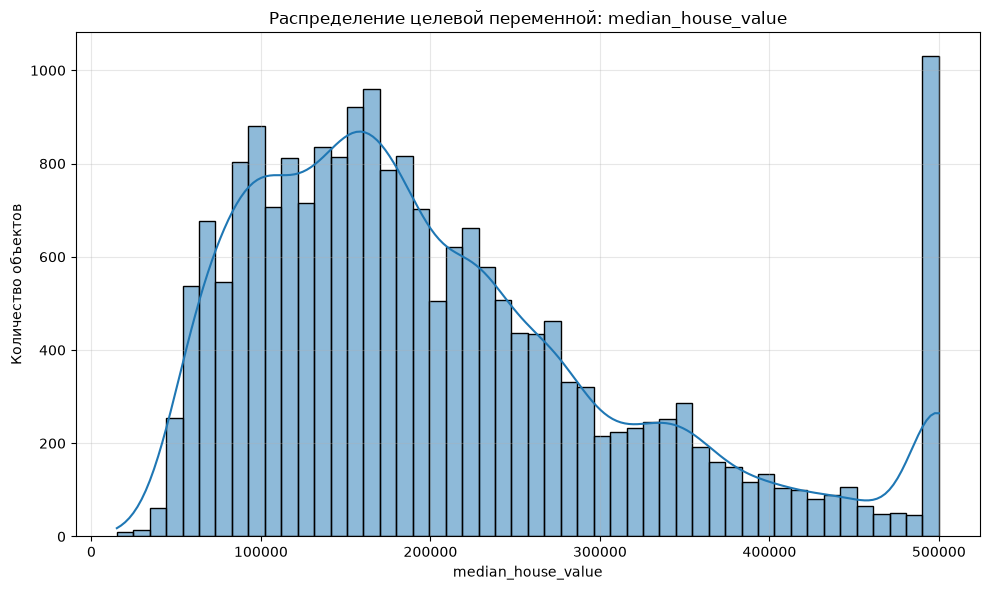

In [134]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=TARGET, bins=50, kde=True)
plt.title(f'Распределение целевой переменной: {TARGET}')
plt.xlabel(TARGET)
plt.ylabel('Количество объектов')
plt.grid(alpha=0.3)
plt.tight_layout()

Видно что распределение не является симметричным. Основная часть наблюдений сосредоточена слева, при этом присутствует большие значения справо. Целевая переменная имеет выраженную неоднородность и содержит большое количество наблюдений в отдельных диапазонах.

### Распределение числовых признаков

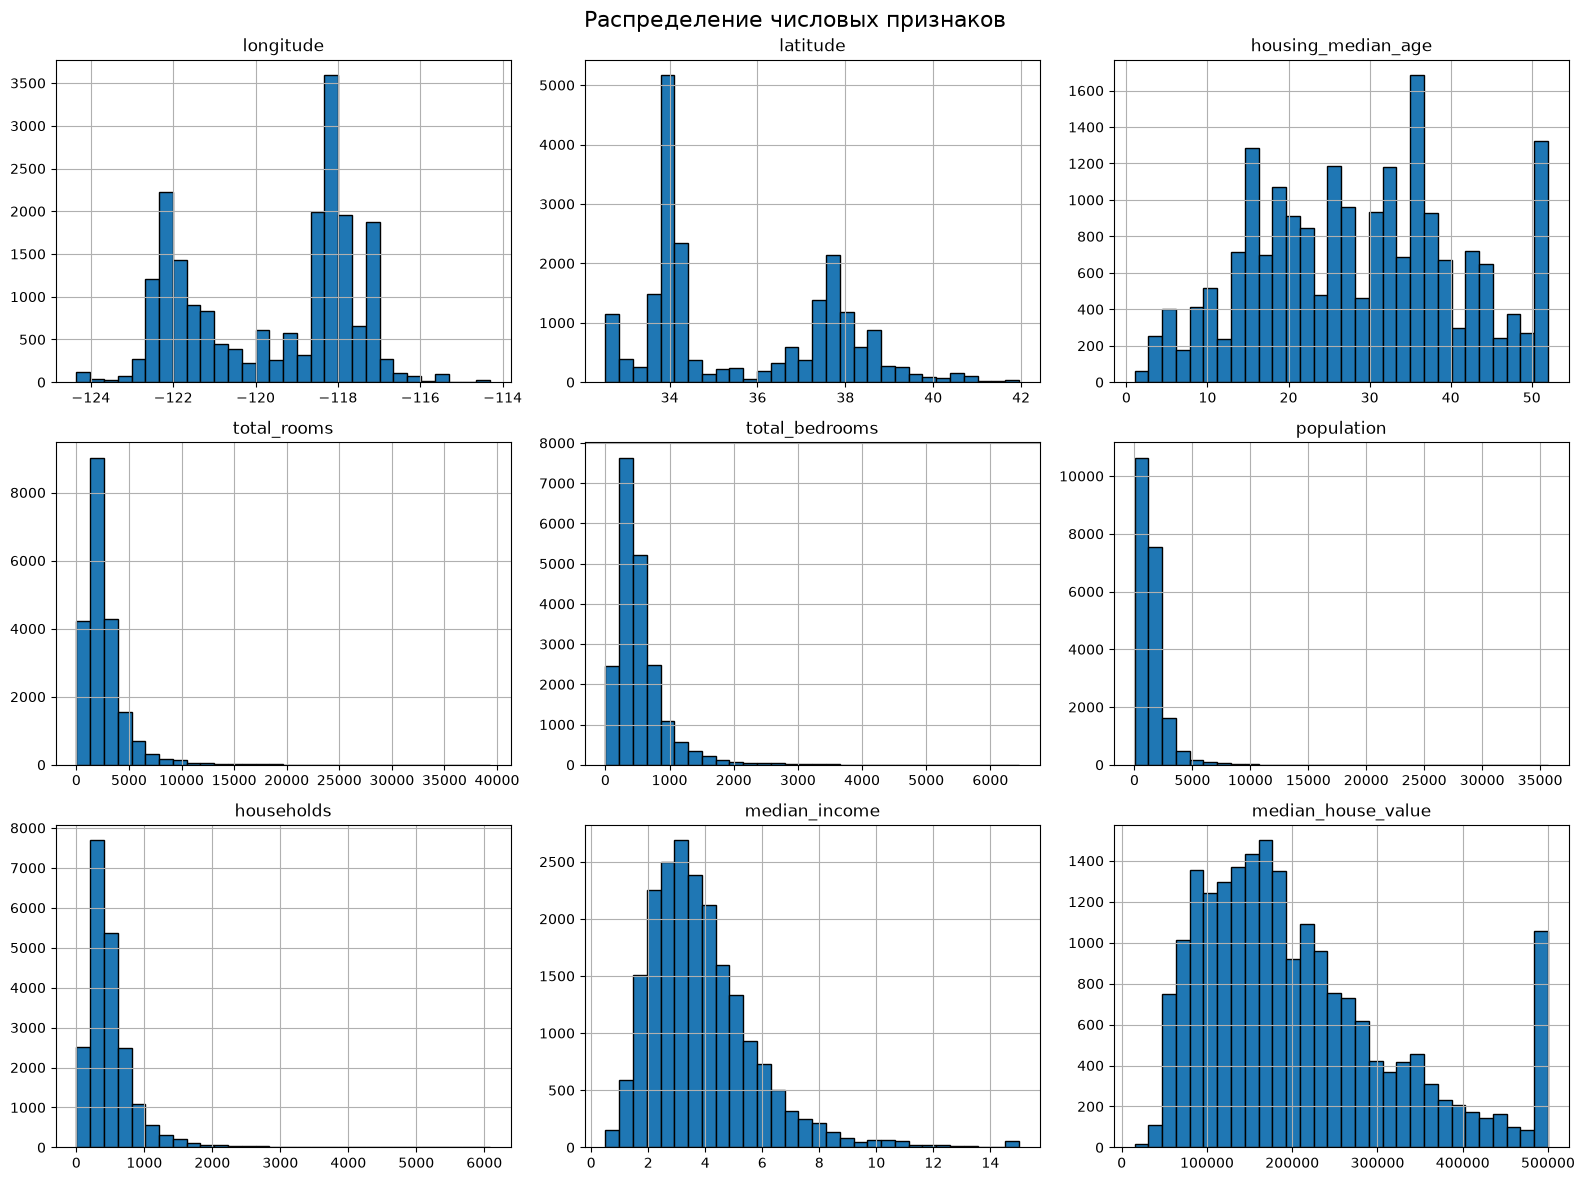

In [135]:
columns_for_hist = numeric_features + [TARGET]

df[columns_for_hist].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black'
)

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout()

На рисунке представлены гистограммы распределения основных числовых признаков датасета. Большинство признаков имеют асимметричные распределения с концентрацией наблюдений в нижней части диапазона и длинным правым хвостом. Особенно выраженная асимметрия наблюдается у признаков total_rooms, total_bedrooms, population и households.

### Выбросы

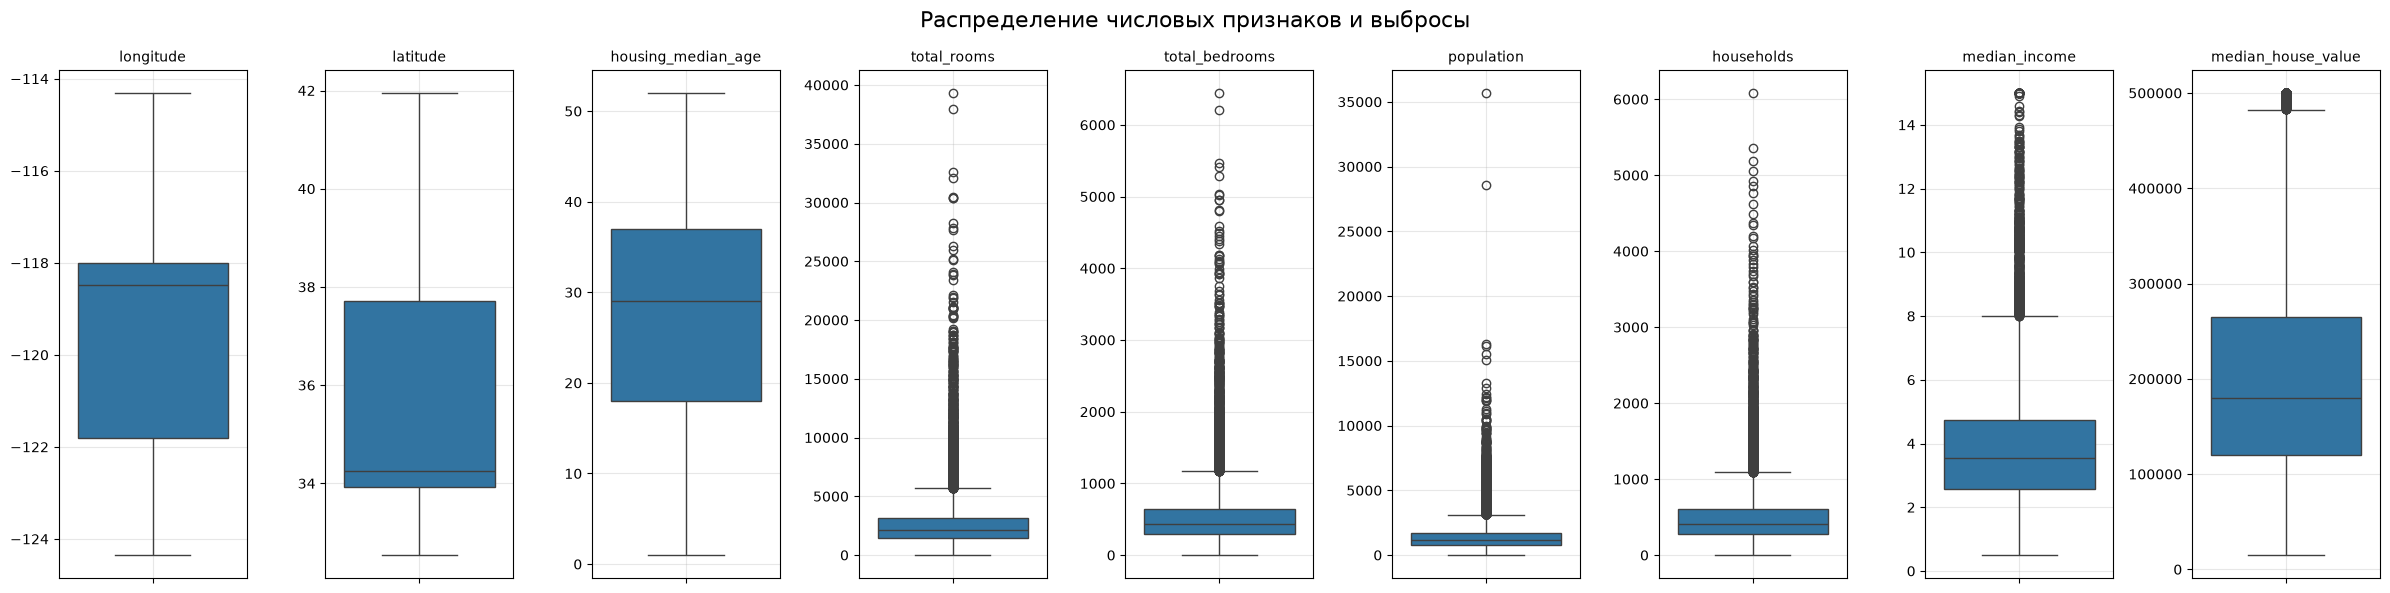

In [136]:

fig, axes = plt.subplots(
    1,
    len(columns_for_hist),
    figsize=(24, 6)
)

for ax, column in zip(axes, columns_for_hist):

    sns.boxplot(
        y=df[column],
        ax=ax
    )

    ax.set_title(column, fontsize=10)
    ax.set_ylabel('')

    ax.grid(alpha=0.3)

plt.suptitle(
    'Распределение числовых признаков и выбросы',
    fontsize=16
)

plt.tight_layout()

Для большинства числовых признаков наблюдается значительное количество точек за пределами основного диапазона. Это свидетельствует о наличии выбросов и сильно различающихся по масштабу значений. Наиболее заметные выбросы наблюдаются у признаков total_rooms, total_bedrooms, population, households и median_income. У них правосторонняя асимметрия: основная масса значений сосредоточена в небольшом диапазоне, а отдельные значения значительно выше верхней границы. Для median_house_value также есть выбросы у верхней границы. Признаки longitude, latitude и housing_median_age имеют меньше выбросов. Числовые признаки сильно различаются по масштабу, поэтому перед применением методов, чувствительных к масштабу, данные будут стандартизированы.

### Распредление обьектов по категориальному признаку

Распределение категориального признака: ocean_proximity
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


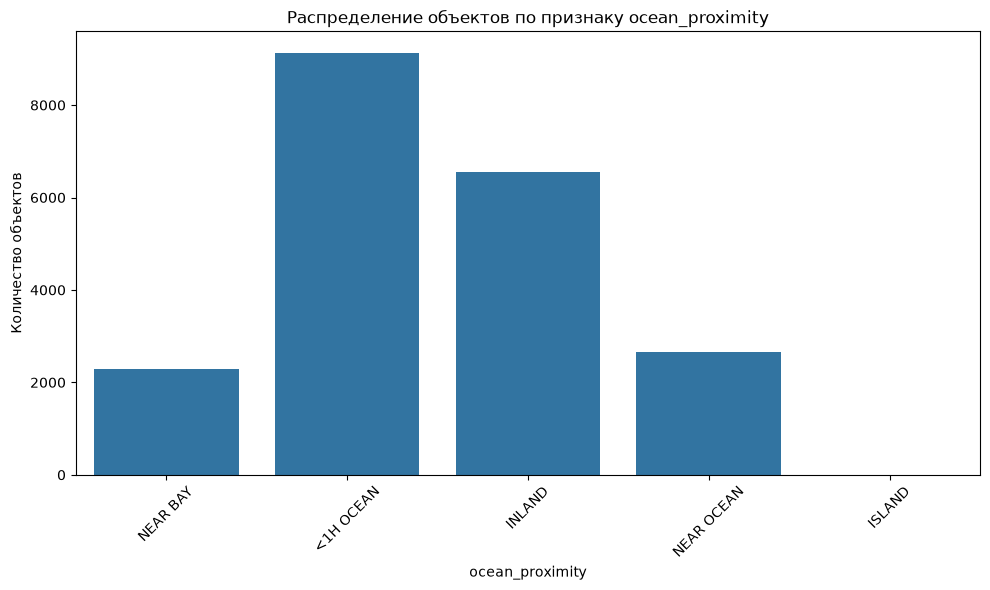

In [137]:
for i, column in enumerate(categorical_features, start=1):

    print('=' * 60)
    print(f'Распределение категориального признака: {column}')
    print('=' * 60)

    print(df[column].value_counts())

    if df[column].nunique() <= 20:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=column)
        plt.title(f'Распределение объектов по признаку {column}')
        plt.xlabel(column)
        plt.ylabel('Количество объектов')
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        print(
            f'У признака {column} слишком много категорий '
            f'({df[column].nunique()}), график не строится.'
        )



Наиболее часто встречается категория <1H OCEAN, далее следует INLAND. Категории NEAR OCEAN и NEAR BAY представлены меньшим количеством наблюдений. Категория ISLAND встречается значительно реже остальных и содержит очень малое количество наблюдений. Распределение категориального признака является неравномерным.

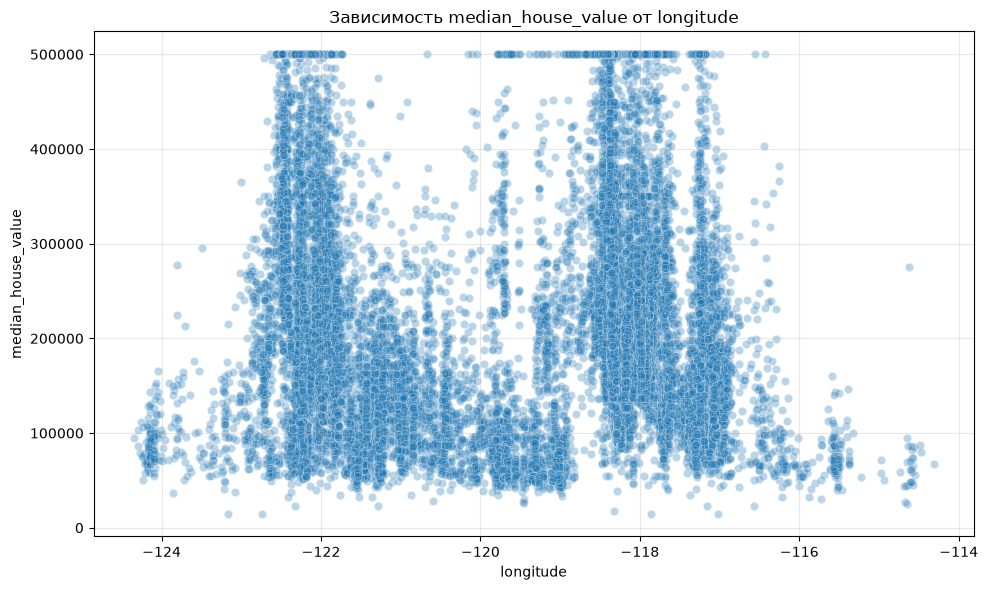

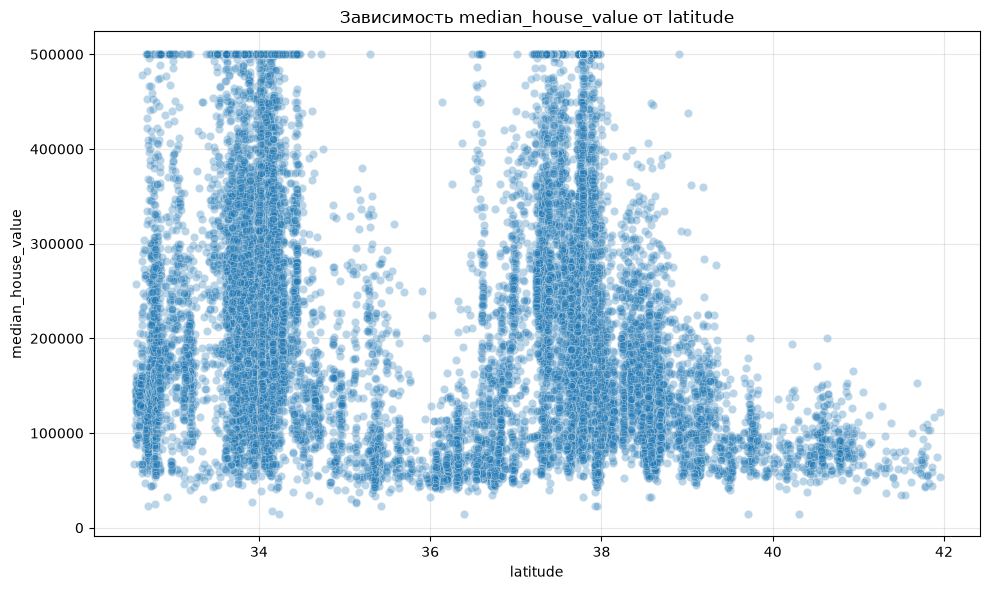

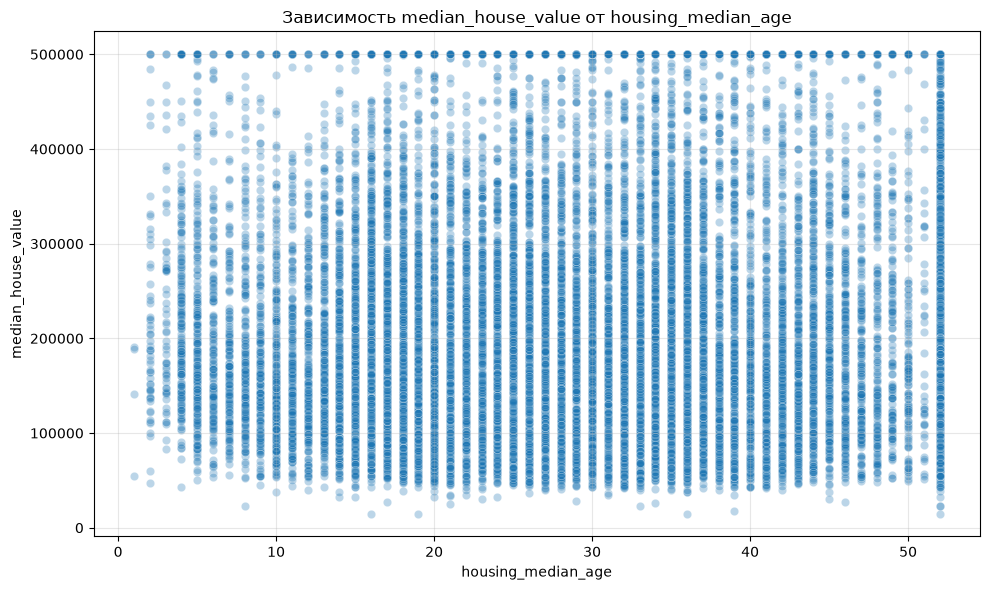

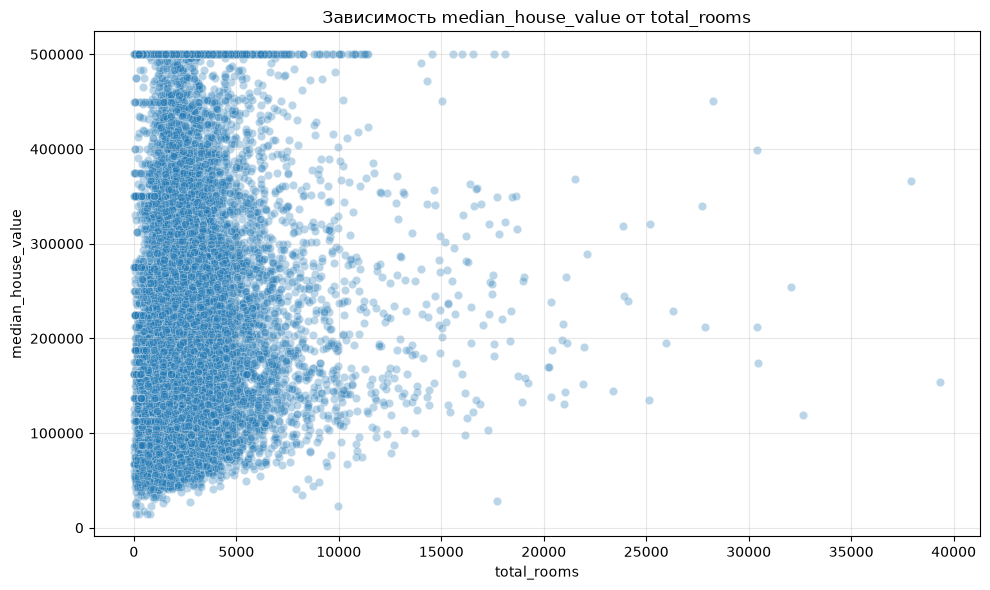

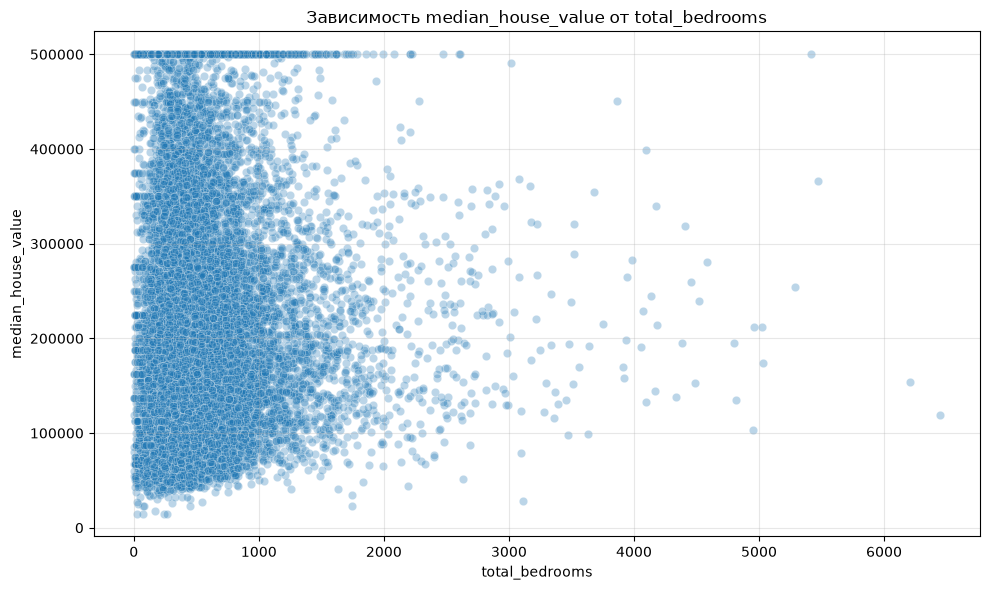

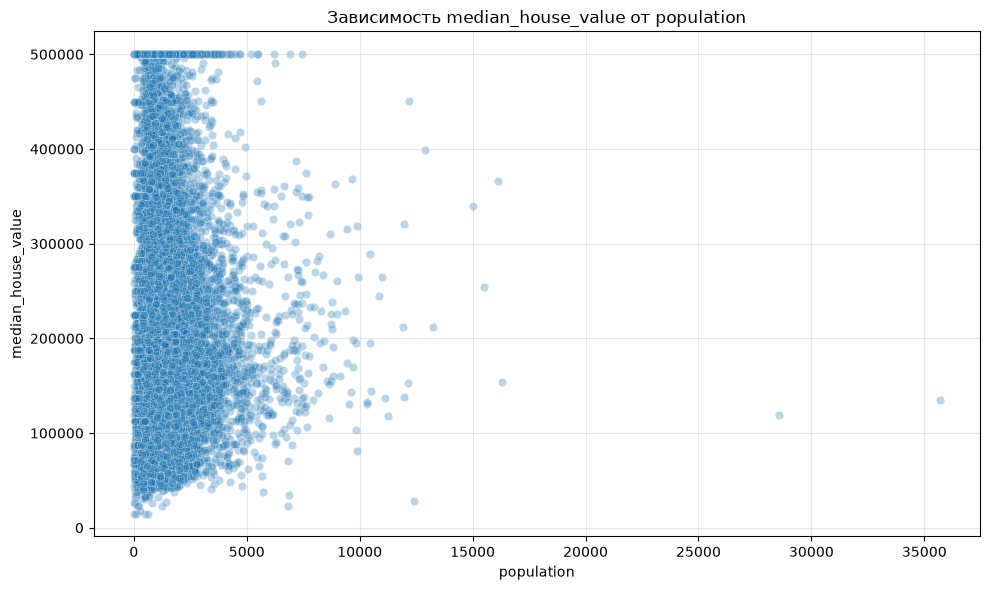

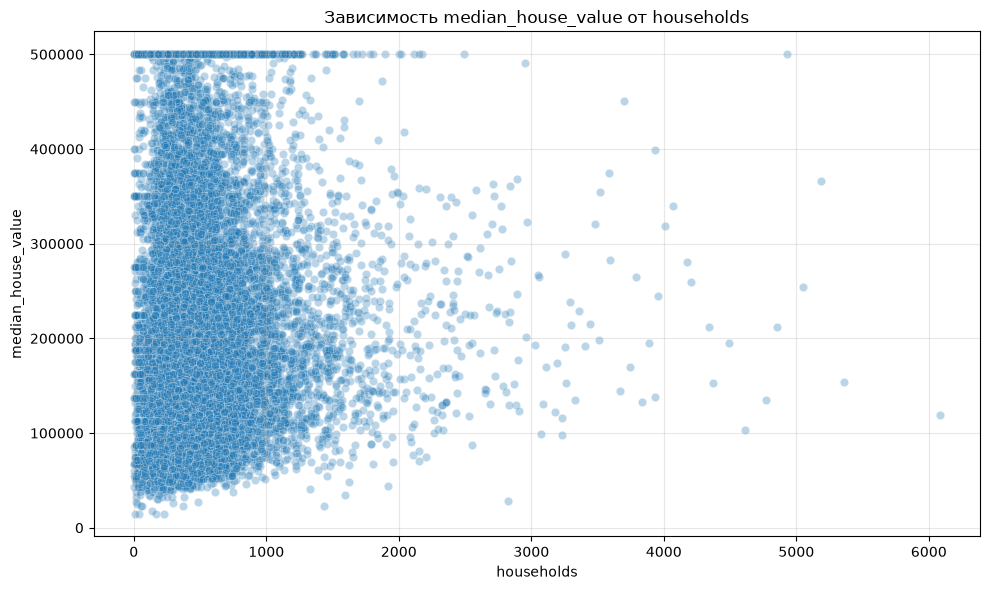

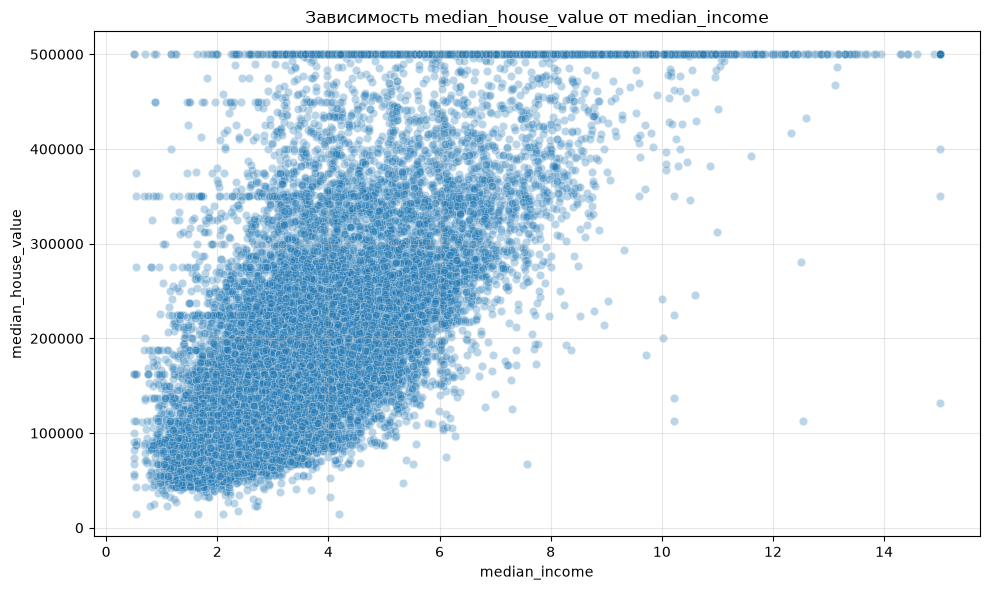

In [138]:
for i, column in enumerate(numeric_features, start=1):

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=column,
        y=TARGET,
        alpha=0.3
    )

    plt.title(f'Зависимость {TARGET} от {column}')
    plt.xlabel(column)
    plt.ylabel(TARGET)
    plt.grid(alpha=0.3)
    plt.tight_layout()

На рисунках представлены диаграммы рассеяния, показывающие зависимость целевого признака median_house_value от числовых признаков набора данных. **На этом этапе мы выбросы не удаляли и признаки ещё не нормировали.**

На графике зависимости стоимости жилья от median_income наблюдается наиболее выраженная положительная зависимость. С увеличением медианного дохода стоимость жилья в целом возрастает. При этом разброс значений увеличивается, а часть объектов достигает верхнего значения стоимости 500000, что указывает на наличие ограничения целевого признака сверху.

Для признаков longitude и latitude наблюдается сложная нелинейная структура. Значения стоимости жилья существенно различаются в зависимости от географического положения, поэтому простая линейная зависимость здесь выражена очень слабо.

Для total_rooms, total_bedrooms, population и households наблюдается общий характер зависимости. При увеличении количества комнат, спален, населения и домохозяйств стоимость жилья в среднем может увеличиваться. Однако точки сильно рассредоточены, поэтому однозначной линейной зависимости не наблюдается.

Для housing_median_age выраженной линейной зависимости со стоимостью жилья практически не наблюдается. Значения целевого признака сильно варьируются при различных значениях возраста домов.

В целом диаграммы рассеяния показывают, что наиболее заметная связь с целевым признаком наблюдается у median_income.

# **Подготовка данных**
### Удаление пропусков


In [139]:
print('=' * 60)
print('ПРЕДОБРАБОТКА ДАННЫХ')
print('=' * 60)

print('\nПропущенные значения до обработки:')
print(df.isnull().sum())

rows_before = len(df)
df = df.dropna().copy()
rows_after = len(df)

print('\nУдаление пропущенных значений:')
print(f'Строк до обработки: {rows_before}')
print(f'Удалено строк: {rows_before - rows_after}')
print(f'Строк после обработки: {rows_after}')

print('\nПропущенные значения после обработки:')
print(df.isnull().sum().sum())

ПРЕДОБРАБОТКА ДАННЫХ

Пропущенные значения до обработки:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Удаление пропущенных значений:
Строк до обработки: 20640
Удалено строк: 207
Строк после обработки: 20433

Пропущенные значения после обработки:
0


Удаление сделано потому, что доля пропусков очень мала, они затрагивают один признак, а потеря 1 % данных не повлияет на выводы.

In [140]:
if categorical_features:

    print('\nКатегориальные признаки:')

    for column in categorical_features:
        print(f'{column}: {df[column].nunique()} категорий')

    df_encoded = pd.get_dummies(
        df,
        columns=categorical_features,
        drop_first=True,
        dtype=int
    )

else:
    print('\nКатегориальных признаков для кодирования нет.')
    df_encoded = df.copy()


print('\nРазмер данных после кодирования:')
print(df_encoded.shape)

print('\nСтолбцы после кодирования:')

for i, column in enumerate(df_encoded.columns, 1):
    print(f'{i}. {column}')

print('\nПервые 5 строк после предобработки:')
print(df_encoded.head())


df_encoded.to_csv(
    'preprocessed_data.csv',
    index=False
)


Категориальные признаки:
ocean_proximity: 5 категорий

Размер данных после кодирования:
(20433, 13)

Столбцы после кодирования:
1. longitude
2. latitude
3. housing_median_age
4. total_rooms
5. total_bedrooms
6. population
7. households
8. median_income
9. median_house_value
10. ocean_proximity_INLAND
11. ocean_proximity_ISLAND
12. ocean_proximity_NEAR BAY
13. ocean_proximity_NEAR OCEAN

Первые 5 строк после предобработки:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88               41.00       880.00          129.00   
1    -122.22     37.86               21.00      7099.00         1106.00   
2    -122.24     37.85               52.00      1467.00          190.00   
3    -122.25     37.85               52.00      1274.00          235.00   
4    -122.25     37.85               52.00      1627.00          280.00   

   population  households  median_income  median_house_value  \
0      322.00      126.00           8.33           452600.

Категориальный признак ocean_proximity (5 категорий) преобразован в числовой вид методом one-hot encoding (pd.get_dummies) с параметром `drop_first=True`. Каждая категория превращается в бинарный столбец (1 - район относится к этой категории, 0 - нет). Первая категория (<1H OCEAN) отбрасывается и служит базовой. Это необходимо, чтобы избежать ловушки фиктивных переменных: сумма всех пяти индикаторов всегда равна единице и дублирует свободный член регрессии, из-за чего возникла бы точная мультиколлинеарность.

В результате получено 4 новых столбца (ocean_proximity_INLAND, ocean_proximity_ISLAND, ocean_proximity_NEAR BAY, ocean_proximity_NEAR OCEAN), а размер таблицы составил **20 433 × 13**: 12 факторов и целевая переменная.

### Стандартизация данных

Как говорилось выше признаки имеют очень разный масштаб. Поэтому пред обучением моделей данные стандартизируются с помощью StandardScaler: из каждого значения вычитается среднее признака и результат делится на стандартное отклонение, $z = (x - \mu)/\sigma$. После этого каждый признак имеет нулевое среднее и единичную дисперсию.
 
StandardScaler не применяется ко всему датасету сразу, а включён в Pipeline вместе с моделью. 

# **Корреляционная матрица и VIF**
### Корреляционная матрица

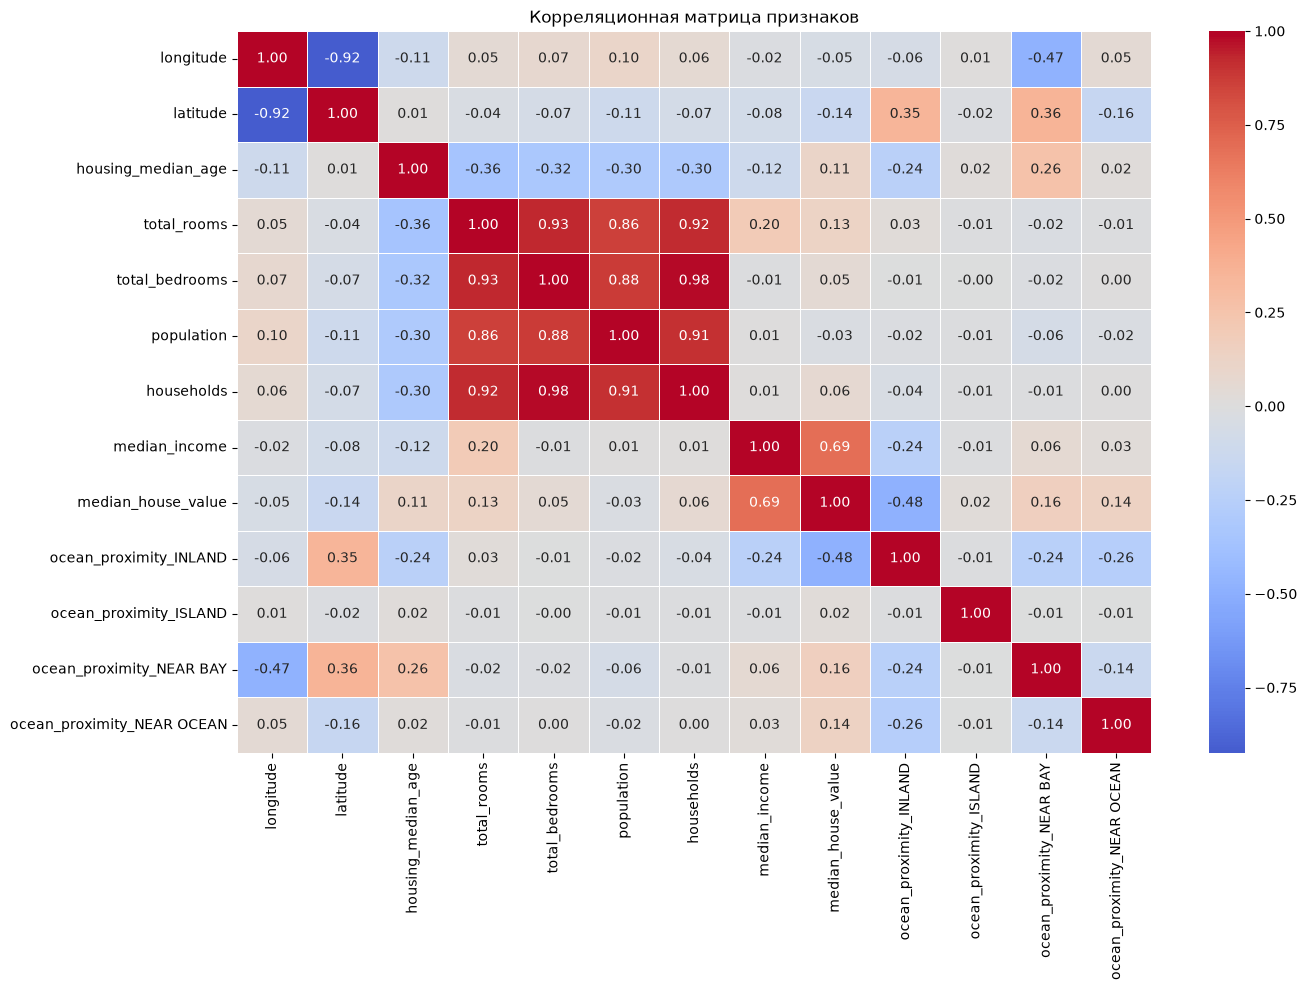

In [141]:
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Корреляционная матрица признаков')

plt.tight_layout()

На тепловой карте показаны коэффициенты корреляции Пирсона между всеми признаками, включая закодированные категории. Сильную связь (|r| ≥ 0,8) имеют **семь пар** признаков:

1. longitude <-> latitude: -0.925
2. total_rooms <-> total_bedrooms: 0.930
3. total_rooms <-> population: 0.857
4. total_rooms <-> households: 0.919
5. total_bedrooms <-> population: 0.878
6. total_bedrooms <-> households: 0.980
7. population <-> households: 0.907

Эти связи объяснимы. Четыре признака - число комнат, число спален, население и число домохозяйств - по сути измеряют одно и то же, *размер района*: чем больше район, тем больше в нём и комнат, и спален, и людей. Долгота и широта связаны отрицательно, потому что штат вытянут вдоль побережья с северо-запада на юго-восток.

С целевой переменной наиболее сильно связаны median_income (r = 0,69) и принадлежность к категории INLAND (r = −0,48: внутренние районы дешевле). Остальные признаки коррелируют с ценой слабо (|r| ≤ 0,16). Таким образом, матрица корреляций указывает на **наличие мультиколлинеарности** среди признаков размера района и среди географических координат.


### Оценка мультиколлинеарности с помощю VIF

In [142]:
X_vif = df_encoded.drop(columns=[TARGET]).astype(float)
X_vif.insert(0, 'const', 1.0)

vif_data = pd.DataFrame()
vif_data['Признак'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data[vif_data['Признак'] != 'const'].reset_index(drop=True)


def vif_interpretation(value):
    if value < 5:
        return 'не выражена'
    elif value < 10:
        return 'возможна заметная'
    else:
        return 'высокая'


vif_data['Мультиколлинеарность'] = vif_data['VIF'].apply(vif_interpretation)
print('\nТаблица VIF (по убыванию):')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))


Таблица VIF (по убыванию):
                   Признак   VIF Мультиколлинеарность
            total_bedrooms 36.31              высокая
                households 35.17              высокая
                  latitude 19.97              высокая
                 longitude 18.09              высокая
               total_rooms 12.97              высокая
                population  6.45    возможна заметная
    ocean_proximity_INLAND  2.86          не выражена
             median_income  1.79          не выражена
  ocean_proximity_NEAR BAY  1.57          не выражена
        housing_median_age  1.32          не выражена
ocean_proximity_NEAR OCEAN  1.20          не выражена
    ocean_proximity_ISLAND  1.00          не выражена


# **Ход работы**
## Регрессионные модели и кросс-валидация
### Подготовка данных
Датасет был разделён на тренировочную (80%) и тестовую (20%) выборки.

In [143]:
print('\n' + "=" * 60)
print("РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ТЕСТОВУЮ ВЫБОРКИ")
print("=" * 60)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print("Целевая переменная: " + TARGET)

print("Количество признаков:", X.shape[1])
print("Количество наблюдений:", X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('\n' + "Разделение данных:")
print("Тренировочная выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

print('\n' + "Среднее значение целевой переменной:")
print(f'train: {y_train.mean():.0f}')
print(f'test:  {y_test.mean():.0f}')


РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ТЕСТОВУЮ ВЫБОРКИ
Целевая переменная: median_house_value
Количество признаков: 12
Количество наблюдений: 20433

Разделение данных:
Тренировочная выборка: (16346, 12)
Тестовая выборка: (4087, 12)

Среднее значение целевой переменной:
train: 206644
test:  207744


Данные разделены на тренировочную (80 %) и тестовую (20 %) выборки функцией train_test_split с фиксированным `random_state=42`, чтобы результаты воспроизводились. В тренировочной выборке **16 346** наблюдений, в тестовой - **4 087**, признаков 12. Средняя стоимость дома в обеих выборках практически одинакова (206 644$ и 207 744$), то есть тестовая выборка репрезентативна.

Тренировочная выборка используется для обучения моделей и кросс-валидации, тестовая - только для итоговой проверки качества. Стандартизация (описана выше) выполняется внутри Pipeline, поэтому на этом шаге данные остаются в исходном масштабе.

### Регрессионные модели
Подсчёт метрик качества (RMSE, R2, MAPE):

In [144]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
}

results = []

for model_name, model in models.items():

    print("Модель:", model_name)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 4))
    print("MAPE:", round(mape, 2), "%")

    results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test R2": r2,
        "Test MAPE (%)": mape
    })
    print("-" * 30)

Модель: Linear Regression
RMSE: 69297.72
R²: 0.6488
MAPE: 28.6 %
------------------------------
Модель: Lasso
RMSE: 69297.72
R²: 0.6488
MAPE: 28.6 %
------------------------------
Модель: Ridge
RMSE: 69297.75
R²: 0.6488
MAPE: 28.59 %
------------------------------


**RMSE** $= \sqrt{\frac{1}{n}\sum (y_i - \hat y_i)^2}$ - среднеквадратичная ошибка, измеряется в тех же единицах, что и целевая переменная (в долларах). Чем меньше, тем лучше; сильнее штрафует большие ошибки.

**R²** $= 1 - \frac{\sum (y_i - \hat y_i)^2}{\sum (y_i - \bar y)^2}$ - доля дисперсии цены, объяснённая моделью. Равен 1 для идеальной модели и 0 для модели, которая всегда предсказывает среднее. Чем больше, тем лучше.

**MAPE** $= \frac{100\%}{n}\sum \left|\frac{y_i - \hat y_i}{y_i}\right|$ - средняя абсолютная ошибка в процентах от фактического значения. Чем меньше, тем лучше; не зависит от масштаба.

Построены три регрессионные модели, каждая обёрнута в Pipeline из двух шагов: стандартизация (StandardScaler) и сама модель.

**Linear Regression** - классическая линейная регрессия, метод наименьших квадратов.

**Lasso** (L1-регуляризация, $\alpha = 0{,}1$) - добавляется штраф $\alpha \sum |w_j|$, который может обнулять коэффициенты и тем самым отбирать признаки.

**Ridge** (гребневая, L2-регуляризация, $\alpha = 1{,}0$) - штраф $\alpha \sum w_j^2$ уменьшает коэффициенты и делает оценки устойчивее при мультиколлинеарности.

Результаты на тестовой выборке:

| Модель | RMSE, $ | R² | MAPE, % |
|---|---|---|---|
| Linear Regression | 69 297,72 | 0,6488 | 28,60 |
| Lasso | 69 297,72 | 0,6488 | 28,60 |
| Ridge | 69 297,75 | 0,6488 | 28,59 |

Все три модели показали **практически одинаковые результаты**. Модель объясняет около 65 % дисперсии стоимости жилья, типичная ошибка прогноза - около `69 тыс. $` при средней цене около `207 тыс. $`, а средняя относительная ошибка составляет около 28,6 %. Высокий MAPE объясняется тем, что для дешёвых районов одна и та же абсолютная ошибка даёт большую относительную.

Совпадение результатов объясняется слабостью регуляризации: целевая переменная измеряется сотнями тысяч долларов, и штраф при $\alpha = 0{,}1$ (Lasso) и $\alpha = 1$ (Ridge) ничтожен по сравнению с суммой квадратов ошибок на 16 тысячах наблюдений. Фактически обе модели совпали с обычной регрессией. Значения $\alpha$ заданы фиксированными и не подбирались.

### Кросс-валидация

In [145]:
print("=" * 81)
print("КРОСС-ВАЛИДАЦИЯ")
print("=" * 81)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():
    
    print("Модель:", model_name)

    y_cv_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv
    )

    cv_rmse = np.sqrt(mean_squared_error(y_train, y_cv_pred))
    cv_r2 = r2_score(y_train, y_cv_pred)

    cv_mape = mean_absolute_percentage_error(
        y_train,
        y_cv_pred
    ) * 100

    
    fold_r2 = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring='r2'
    )

    print("CV RMSE:", round(cv_rmse, 2))
    print("CV R²:", round(cv_r2, 4))
    print("CV MAPE:", round(cv_mape, 2), "%")
    print(f'R² по фолдам: {np.round(fold_r2, 4)}, среднее {fold_r2.mean():.4f} ± {fold_r2.std():.4f}')
    print("-" * 81)

    cv_results.append({
        "Model": model_name,
        "CV RMSE": cv_rmse,
        "CV R2": cv_r2,
        "CV MAPE (%)": cv_mape
    })
    

results_df = pd.DataFrame(results)
cv_results_df = pd.DataFrame(cv_results)
final_results = results_df.merge(
    cv_results_df,
    on="Model"
)
print("=" * 81)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 81)

print(
    final_results.round(4).to_string(index=False)
)

КРОСС-ВАЛИДАЦИЯ
Модель: Linear Regression
CV RMSE: 68729.51
CV R²: 0.6431
CV MAPE: 28.68 %
R² по фолдам: [0.6571 0.6579 0.6475 0.6275 0.6245], среднее 0.6429 ± 0.0143
---------------------------------------------------------------------------------
Модель: Lasso
CV RMSE: 68729.5
CV R²: 0.6431
CV MAPE: 28.68 %
R² по фолдам: [0.6571 0.6579 0.6475 0.6275 0.6245], среднее 0.6429 ± 0.0143
---------------------------------------------------------------------------------
Модель: Ridge
CV RMSE: 68729.0
CV R²: 0.6431
CV MAPE: 28.68 %
R² по фолдам: [0.6571 0.6579 0.6475 0.6275 0.6246], среднее 0.6429 ± 0.0143
---------------------------------------------------------------------------------
ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
            Model  Test RMSE  Test R2  Test MAPE (%)  CV RMSE  CV R2  CV MAPE (%)
Linear Regression   69297.72     0.65          28.60 68729.51   0.64        28.68
            Lasso   69297.72     0.65          28.60 68729.50   0.64        28.68
            Ridge   69297.75     0.65 

Для более надёжной оценки применена **5-кратная кросс-валидация** на тренировочной выборке. Она разбивает тренировочные данные на пять частей: модель по очереди обучается на четырёх и предсказывает пятую, так что у каждого наблюдения появляется "честный" прогноз модели, не видевшей его при обучении (cross_val_predict). По этим прогнозам считаются метрики. Дополнительно через cross_val_score получен R² на каждом из пяти фолдов.

| Модель | CV RMSE, $ | CV R² | CV MAPE, % |
|---|---|---|---|
| Linear Regression | 68 729,5 | 0,6431 | 28,68 |
| Lasso | 68 729,5 | 0,6431 | 28,68 |
| Ridge | 68 729,0 | 0,6431 | 28,68 |

Кросс-валидационные метрики очень близки к тестовым (R² 0,643 против 0,649; RMSE 68,7 тыс. против 69,3 тыс. $; MAPE 28,7 % против 28,6 %). R² по фолдам лежит в диапазоне от 0,625 до 0,658 (среднее 0,643 ± 0,014), то есть качество устойчиво и не зависит от конкретного разбиения. Это говорит об **отсутствии переобучения**: на новых данных модель работает так же, как на обучающих.

### Фактические и предсказанные значения

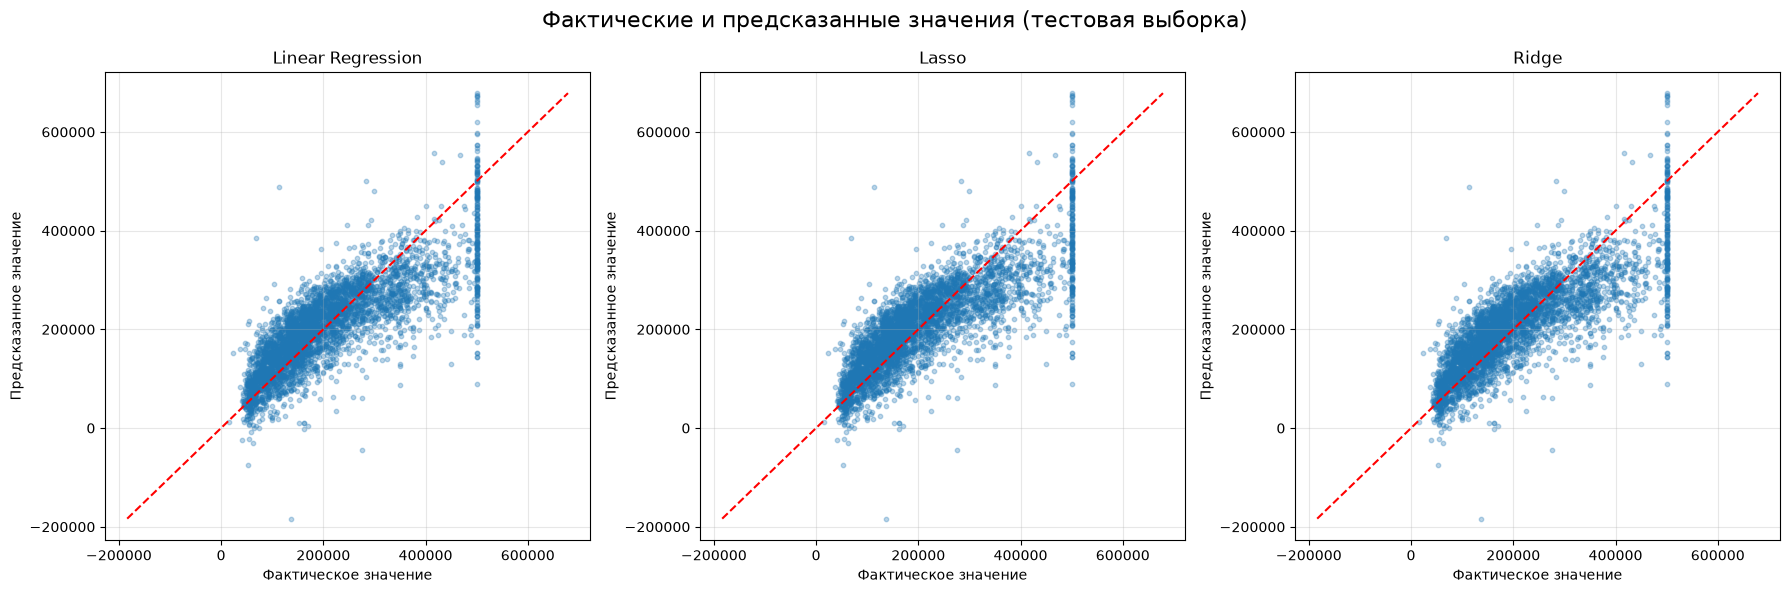

In [146]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model_name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10)

    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    ax.plot([min_value, max_value], [min_value, max_value], 'r--')

    ax.set_xlabel('Фактическое значение')
    ax.set_ylabel('Предсказанное значение')
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

plt.suptitle('Фактические и предсказанные значения (тестовая выборка)', fontsize=16)
plt.tight_layout()

На графиках по горизонтали отложена фактическая стоимость, по вертикали - предсказанная, красная пунктирная линия соответствует идеальному предсказанию. Облако точек вытянуто вдоль диагонали, то есть модели в целом улавливают зависимость, но разброс вокруг неё значительный.

Заметны три особенности. Во-первых, вертикальный столбец точек при фактической цене 500000$ - это районы с усечённой стоимостью, для которых предсказания разбросаны очень широко. Во-вторых, облако наклонено относительно диагонали: дешёвые районы модель в основном завышает, а дорогие занижает. В-третьих, встречаются **отрицательные предсказания**, что невозможно для цены. Графики трёх моделей практически неразличимы.

### Анализ остатков модели

Анализ остатков и тест Бройша-Пагана:
            Model  Среднее остатков  Std остатков  Breusch-Pagan LM  p-value
Linear Regression        1,474.1442   69,290.5129          196.7624   0.0000
            Lasso        1,474.1547   69,290.5147          196.7670   0.0000
            Ridge        1,474.2547   69,290.5405          196.9160   0.0000

Остатки по квартилям предсказанных значений (Linear Regression):
             count    mean    std
Группа                           
1 (низкие)    1022   7,080 47,869
2             1022 -12,692 61,982
3             1021  -6,964 75,005
4 (высокие)   1022  18,464 82,875


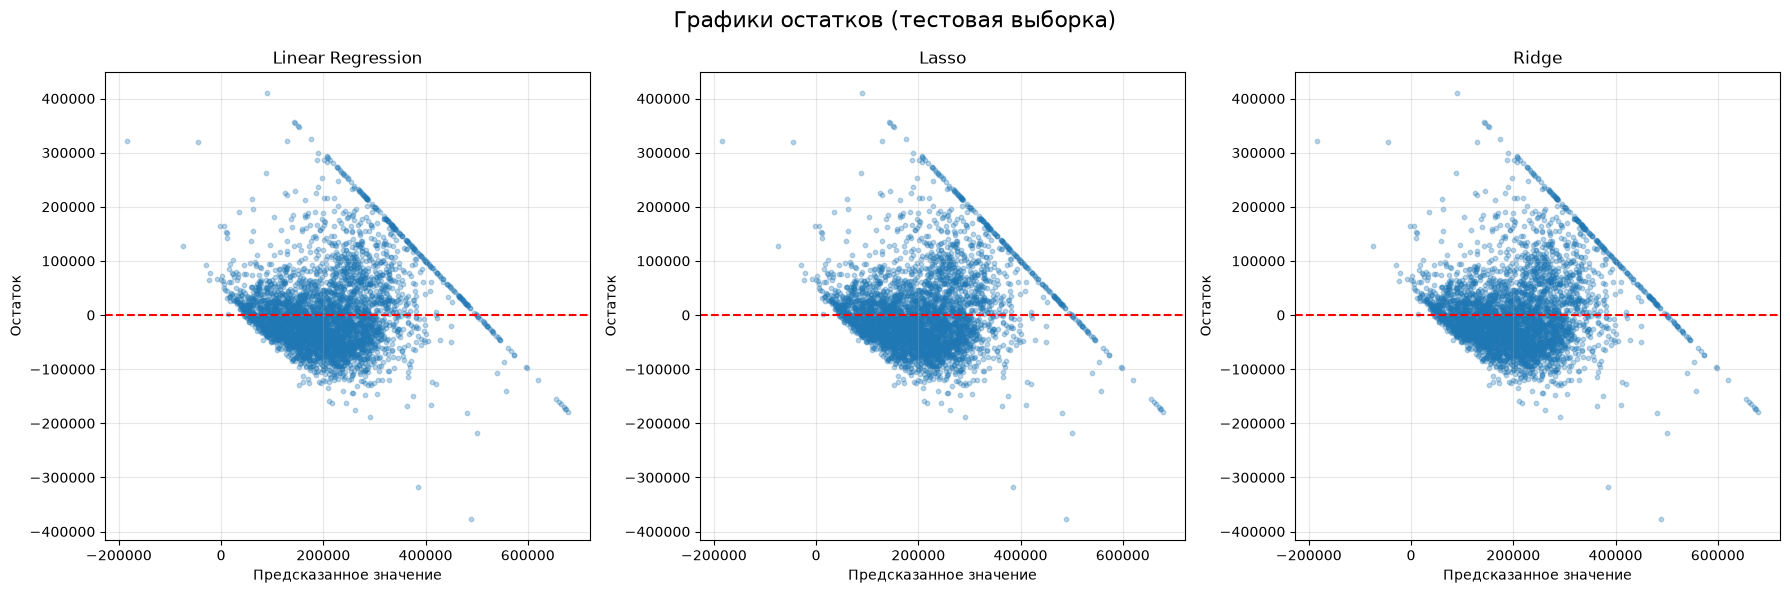

In [147]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bp_results = []

for ax, (model_name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--')
    ax.set_xlabel('Предсказанное значение')
    ax.set_ylabel('Остаток')
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

    lm_statistic, lm_pvalue, _, _ = het_breuschpagan(residuals, sm.add_constant(X_test))

    bp_results.append({
        'Model': model_name,
        'Среднее остатков': residuals.mean(),
        'Std остатков': residuals.std(),
        'Breusch-Pagan LM': lm_statistic,
        'p-value': lm_pvalue
    })

plt.suptitle('Графики остатков (тестовая выборка)', fontsize=16)
plt.tight_layout()

print('Анализ остатков и тест Бройша-Пагана:')
print(pd.DataFrame(bp_results).to_string(index=False, float_format=lambda v: f'{v:,.4f}'))

y_pred = models['Linear Regression'].predict(X_test)
residual_df = pd.DataFrame({'pred': y_pred, 'resid': y_test - y_pred})
residual_df['Группа'] = pd.qcut(
    residual_df['pred'], 4,
    labels=['1 (низкие)', '2', '3', '4 (высокие)']
)

print('\nОстатки по квартилям предсказанных значений (Linear Regression):')
print(
    residual_df.groupby('Группа', observed=True)['resid']
    .agg(['count', 'mean', 'std'])
    .to_string(float_format=lambda v: f'{v:,.0f}')
)

Остаток - это разность между фактическим и предсказанным значением. На графиках по горизонтали отложено предсказание, по вертикали - остаток (красная  пунктирная линия). Если модель адекватна, а дисперсия ошибок постоянна (**гомоскедастичность**), остатки должны образовывать равномерную полосу вокруг нуля без видимой структуры.

Здесь этого нет:

- Чётко выделяется **наклонная линия** точек - это районы с усечённой ценой 500000$: остаток для них равен 500000 минус предсказание, поэтому он тем больше, чем ниже предсказание.
- Разброс остатков растёт вместе с предсказанным значением. Для четырёх групп по квартилям предсказания стандартное отклонение остатков равно 47 869, 61 982, 75 005 и 82 875, то есть в группе дорогих районов ошибки примерно в 1,7 раза больше, чем в группе дешёвых.
- Средние остатки по группам не равны нулю (+7 080, -12 692, -6 964, +18 464): ошибки систематически зависят от уровня предсказания, то есть линейная модель не улавливает часть нелинейности.

Формально гетероскедастичность проверена **тестом Бройша–Пагана** (нулевая гипотеза - гомоскедастичность): статистика LM приблизительно 196,8, p-value < 0,001. Нулевая гипотеза отвергается, то есть **дисперсия ошибок не постоянна - присутствует гетероскедастичность**. Общее среднее остатков около +1 474$ (близко к нулю, глобального смещения нет), стандартное отклонение - около 69 290$; для всех трёх моделей результаты совпадают.

Гетероскедастичность нарушает одно из допущений классической линейной регрессии: оценки коэффициентов остаются несмещёнными, но их стандартные ошибки и доверительные интервалы становятся ненадёжными. Улучшить ситуацию можно логарифмированием целевой переменной или использованием робастных стандартных ошибок.

## PCA

Метод главных компонент (PCA) преобразует набор коррелированных признаков в новый набор **некоррелированных** главных компонент - линейных комбинаций исходных признаков, упорядоченных по убыванию объяснённой дисперсии. Компоненты ортогональны друг другу, поэтому мультиколлинеарность между ними отсутствует по построению. Кроме того, можно оставить только первые компоненты и тем самым снизить размерность.

Перед PCA данные стандартизованы: StandardScaler и PCA обучаются только на тренировочной выборке, чтобы не допустить утечки данных из тестовой.

In [148]:
print('=' * 60)
print('МЕТОД ГЛАВНЫХ КОМПОНЕНТ (PCA)')
print('=' * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

n_total = len(pca_full.explained_variance_ratio_)

pca_table = pd.DataFrame({
    'Компонента': [f'PC{i}' for i in range(1, n_total + 1)],
    'Собственное значение': pca_full.explained_variance_,
    'Доля дисперсии': pca_full.explained_variance_ratio_,
    'Накопленная доля': np.cumsum(pca_full.explained_variance_ratio_)
})

print(pca_table.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

N_COMPONENTS = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1)
n_kaiser = int((pca_full.explained_variance_ > 1).sum())

print('\nКомпонент для сохранения 95% дисперсии:', N_COMPONENTS)
print('Компонент по критерию Кайзера (собственное значение > 1):', n_kaiser)

МЕТОД ГЛАВНЫХ КОМПОНЕНТ (PCA)
Компонента  Собственное значение  Доля дисперсии  Накопленная доля
       PC1                3.9056          0.3254            0.3254
       PC2                2.2528          0.1877            0.5132
       PC3                1.5481          0.1290            0.6422
       PC4                1.0757          0.0896            0.7318
       PC5                1.0001          0.0833            0.8151
       PC6                0.9771          0.0814            0.8965
       PC7                0.5729          0.0477            0.9443
       PC8                0.4146          0.0345            0.9788
       PC9                0.1513          0.0126            0.9914
      PC10                0.0612          0.0051            0.9965
      PC11                0.0262          0.0022            0.9987
      PC12                0.0154          0.0013            1.0000

Компонент для сохранения 95% дисперсии: 8
Компонент по критерию Кайзера (собственное значение > 1)

В таблице для каждой компоненты приведены собственное значение, доля объяснённой дисперсии и накопленная доля. Всего 12 компонент - по числу признаков.

Первая компонента объясняет 32,5 % общей дисперсии, вторая - 18,8 %, третья - 12,9 %. Чтобы сохранить не менее **95 %** дисперсии, нужно **8 компонент** (накопленная доля 97,9 %; семь компонент дают 94,4 %, этого недостаточно). По критерию Кайзера (оставлять компоненты с собственным значением больше 1) получилось бы 5 компонент, но PC5 (1,0001) находится ровно на границе, а PC6 (0,977) почти равна единице, поэтому этот критерий здесь не очень надёжен. Для дальнейшей работы выбрано **8 компонент**: размерность снижается с 12 до 8, то есть на треть.

### График каменистой осыпи

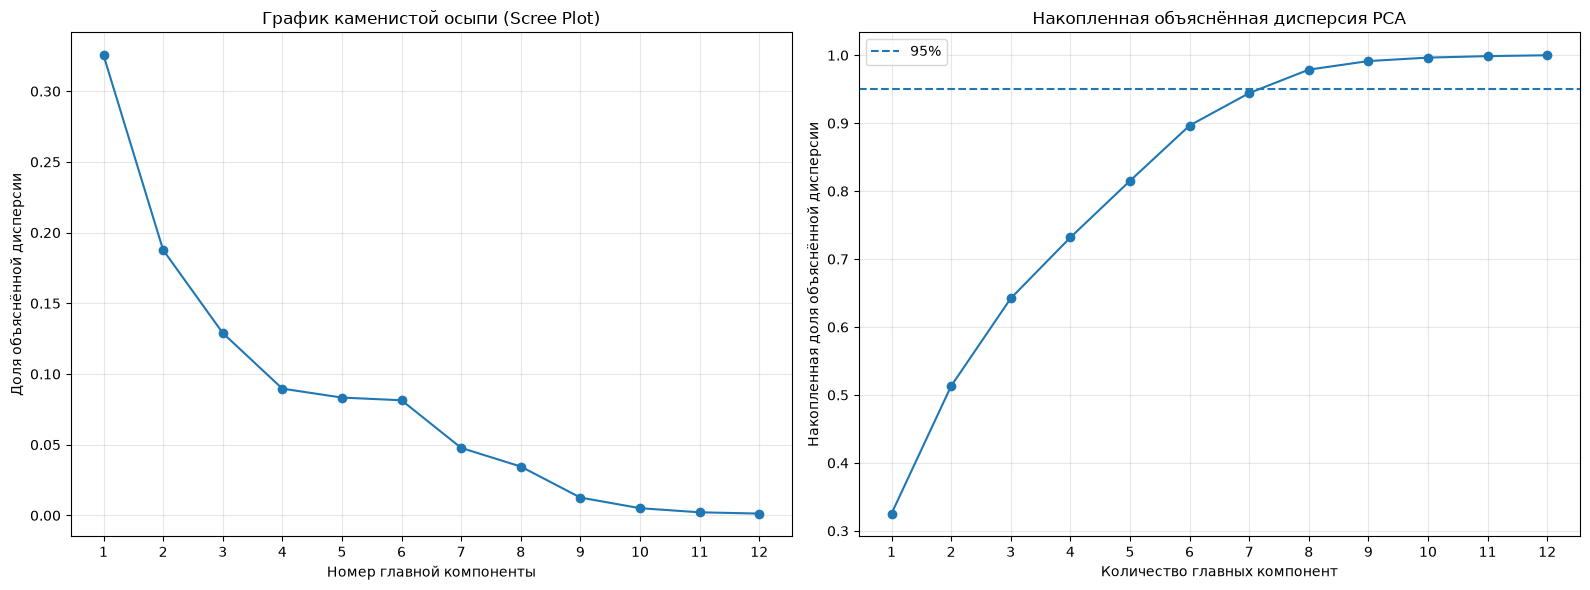

In [ ]:
ratios = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratios)

n_total = len(ratios)
x_axis = np.arange(1, n_total + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    x_axis,
    ratios,
    marker="o"
)

axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Доля объяснённой дисперсии")
axes[0].set_title("График каменистой осыпи (Scree Plot)")
axes[0].set_xticks(x_axis)
axes[0].grid(alpha=0.3)

axes[1].plot(
    x_axis,
    cumulative,
    marker="o"
)

axes[1].axhline(
    0.95,
    linestyle="--",
    label="95%"
)

axes[1].set_xlabel("Количество главных компонент")
axes[1].set_ylabel("Накопленная доля объяснённой дисперсии")
axes[1].set_title("Накопленная объяснённая дисперсия PCA")
axes[1].set_xticks(x_axis)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

На графике каменистой осыпи (scree plot) точки показывают долю дисперсии каждой компоненты. А РСА - накопленную долю, пунктир - порог 95 %. Видно резкое падение после первых трёх компонент ("излом" на 3–4 компонентах), затем идёт плавный спад, а потом еще один "излом" на 6-7 компанентах.  Накопленная кривая пересекает порог 95 % на восьмой компоненте, а 7 компонент близок к этому, что подтверждает выбор числа компонент.

## Регрессионные модели после PCA

In [ ]:
pca_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS)),
        ("model", LinearRegression())
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS)),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS)),
        ("model", Ridge(alpha=1.0))
    ])
}

pca_test_results = []
pca_cv_results = []

for model_name, model in pca_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    print(f"{model_name} - тест:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    
    pca_test_results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test R2": r2,
        "Test MAPE (%)": mape
    })
    
    # Кросс-валидация
    y_cv_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv
    )
    
    rmse_cv = np.sqrt(mean_squared_error(y_train, y_cv_pred))
    r2_cv = r2_score(y_train, y_cv_pred)
    mape_cv = mean_absolute_percentage_error(y_train, y_cv_pred) * 100
    
    print(f"Кросс-валидация:")
    print(f"RMSE: {rmse_cv:.2f}")
    print(f"R²: {r2_cv:.4f}")
    print(f"MAPE: {mape_cv:.2f}%")
    print()
    
    pca_cv_results.append({
        "Model": model_name,
        "CV RMSE": rmse_cv,
        "CV R2": r2_cv,
        "CV MAPE (%)": mape_cv
    })

after_pca = (
    pd.DataFrame(pca_test_results)
    .set_index("Model")
    .join(
        pd.DataFrame(pca_cv_results).set_index("Model")
    )
)

Linear Regression - тест:
RMSE: 73732.60
R²: 0.6025
MAPE: 29.66%
Кросс-валидация:
RMSE: 72638.46
R²: 0.6014
MAPE: 29.92%

Lasso - тест:
RMSE: 73732.59
R²: 0.6025
MAPE: 29.66%
Кросс-валидация:
RMSE: 72638.46
R²: 0.6014
MAPE: 29.92%

Ridge - тест:
RMSE: 73732.57
R²: 0.6025
MAPE: 29.66%
Кросс-валидация:
RMSE: 72638.45
R²: 0.6014
MAPE: 29.92%



Построены те же три модели (Linear Regression, Lasso, Ridge с теми же $\alpha$), но теперь на вход подаются 8 главных компонент вместо 12 исходных признаков. Каждая модель - Pipeline из трёх шагов: StandardScaler, PCA(8), регрессия. Скейлер и PCA обучаются внутри каждого фолда кросс-валидации только на обучающей части, поэтому утечки данных нет. Метрики посчитаны и на тестовой выборке, и по кросс-валидации.

| Модель | Test RMSE, $ | Test R² | Test MAPE, % | CV RMSE, $ | CV R² | CV MAPE, % |
|---|---|---|---|---|---|---|
| Linear Regression | 73 732,6 | 0,6025 | 29,66 | 72 638,5 | 0,6014 | 29,92 |
| Lasso | 73 732,6 | 0,6025 | 29,66 | 72 638,5 | 0,6014 | 29,92 |
| Ridge | 73 732,6 | 0,6025 | 29,66 | 72 638,5 | 0,6014 | 29,92 |

Как и на исходных признаках, три модели дали одинаковый результат (по той же причине - слишком слабая регуляризация).

### Сравнение метрик до и после PCA

In [151]:
before_pca = pd.DataFrame({
    "Test RMSE": [69297.72, 69297.72, 69297.75],
    "Test R2": [0.6488, 0.6488, 0.6488],
    "Test MAPE (%)": [28.60, 28.60, 28.59],
    "CV RMSE": [68729.51, 68729.50, 68729.00],
    "CV R2": [0.6431, 0.6431, 0.6431],
    "CV MAPE (%)": [28.68, 28.68, 28.68]
}, index=["Linear Regression", "Lasso", "Ridge"])

after_pca = pd.DataFrame({
    "Test RMSE": [73732.60, 73732.59, 73732.57],
    "Test R2": [0.6025, 0.6025, 0.6025],
    "Test MAPE (%)": [29.66, 29.66, 29.66],
    "CV RMSE": [72638.46, 72638.46, 72638.45],
    "CV R2": [0.6014, 0.6014, 0.6014],
    "CV MAPE (%)": [29.92, 29.92, 29.92]
}, index=["Linear Regression", "Lasso", "Ridge"])

print("ДО PCA:")
print(before_pca.round(4))

print(f"\nПОСЛЕ PCA ({N_COMPONENTS} компонент):")
print(after_pca.round(4))

print("\nИзменение (после − до):")
print((after_pca - before_pca).round(4))

print("\nИзменение, %:")
print(((after_pca / before_pca - 1) * 100).round(2))

comparison_df = pd.concat(
    [before_pca.add_prefix("До PCA "),
     after_pca.add_prefix("После PCA ")],
    axis=1
)

ДО PCA:
                   Test RMSE  Test R2  Test MAPE (%)  CV RMSE  CV R2  \
Linear Regression   69297.72     0.65          28.60 68729.51   0.64   
Lasso               69297.72     0.65          28.60 68729.50   0.64   
Ridge               69297.75     0.65          28.59 68729.00   0.64   

                   CV MAPE (%)  
Linear Regression        28.68  
Lasso                    28.68  
Ridge                    28.68  

ПОСЛЕ PCA (8 компонент):
                   Test RMSE  Test R2  Test MAPE (%)  CV RMSE  CV R2  \
Linear Regression   73732.60     0.60          29.66 72638.46   0.60   
Lasso               73732.59     0.60          29.66 72638.46   0.60   
Ridge               73732.57     0.60          29.66 72638.45   0.60   

                   CV MAPE (%)  
Linear Regression        29.92  
Lasso                    29.92  
Ridge                    29.92  

Изменение (после − до):
                   Test RMSE  Test R2  Test MAPE (%)  CV RMSE  CV R2  \
Linear Regression    4434.8

Сводное сравнение на тестовой выборке:

| Метрика | Исходные признаки (12) | PCA (8 компонент) | Изменение |
|---|---|---|---|
| RMSE, $ | 69 297,7 | 73 732,6 | +4 435 (+6,4 %) |
| R² | 0,6488 | 0,6025 | −0,046 (−7,1 %) |
| MAPE, % | 28,60 | 29,66 | +1,06 п. п. (+3,7 %) |

По кросс-валидации картина та же: RMSE вырос с 68 730 до 72 638 $ (+5,7 %), R² снизился с 0,643 до 0,601, MAPE вырос с 28,68 до 29,92 % (+1,24 п. п.). Для всех трёх моделей изменения одинаковы. После PCA качество **немного ухудшилось по всем трём метрикам**.

### Изменения RMSE

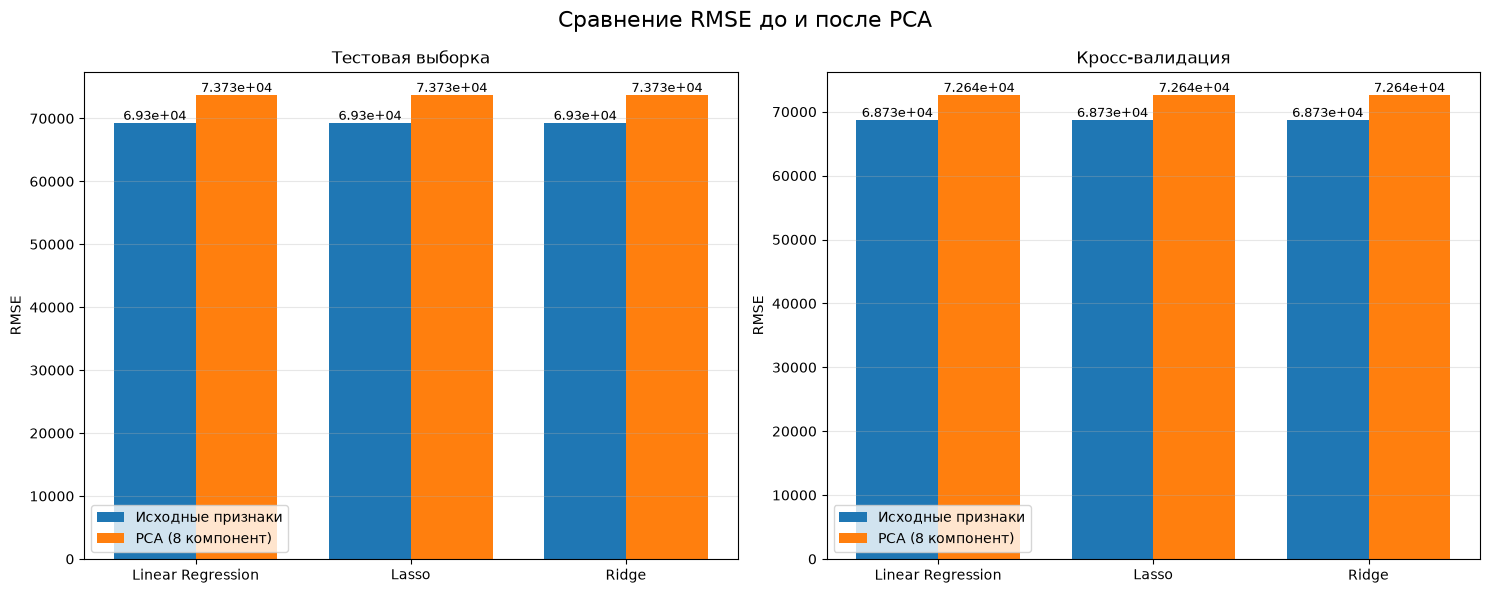

In [152]:
def Plot_Comparison(metric, ylabel):

    labels = list(before_pca.index)
    pos = np.arange(len(labels))
    width = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, prefix, title in zip(axes, ['Test', 'CV'], ['Тестовая выборка', 'Кросс-валидация']):

        bars_before = ax.bar(pos - width / 2, before_pca[f'{prefix} {metric}'], width, label='Исходные признаки')
        bars_after = ax.bar(pos + width / 2, after_pca[f'{prefix} {metric}'], width, label=f'PCA ({N_COMPONENTS} компонент)')

        ax.bar_label(bars_before, fmt='%.4g', fontsize=9)
        ax.bar_label(bars_after, fmt='%.4g', fontsize=9)

        ax.set_xticks(pos)
        ax.set_xticklabels(labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
        ax.legend()

    plt.suptitle(f'Сравнение {ylabel} до и после PCA', fontsize=16)
    plt.tight_layout()


Plot_Comparison('RMSE', 'RMSE')

На диаграмме сравнивается RMSE моделей до и после PCA: слева - на тестовой выборке, справа - по кросс-валидации. После PCA ошибка выросла: на тесте с 69 298 до 73 733$ (на 6,4 %), по кросс-валидации с 68 730 до 72 638 $ (на 5,7 %). Столбцы трёх моделей внутри каждой пары практически одинаковы, то есть различие обусловлено не типом модели, а набором признаков.

### Изменения R2

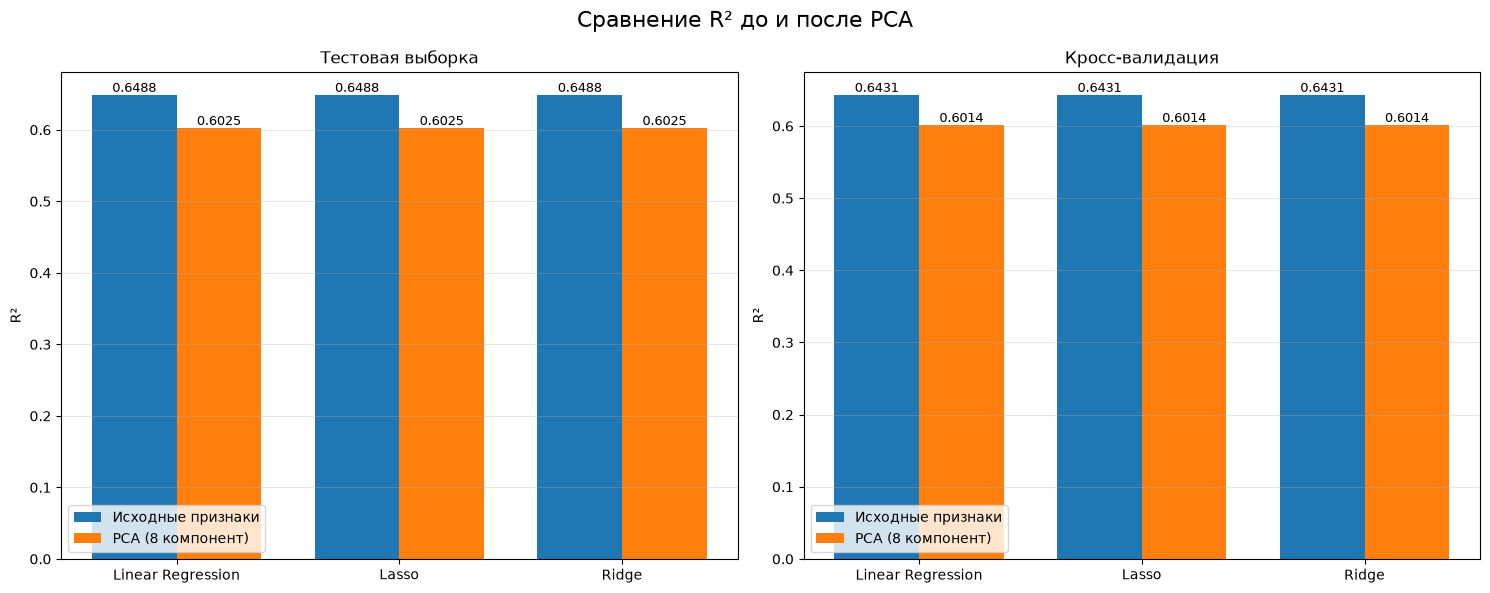

In [153]:
Plot_Comparison('R2', 'R²')

R² после PCA снизился: на тесте с 0,6488 до 0,6025, по кросс-валидации с 0,6431 до 0,6014. Иными словами, модель на 8 главных компонентах объясняет примерно на 4-5 процентных пунктов меньше дисперсии стоимости жилья. Для всех трёх моделей изменение одинаково.

### Изменения MAPE

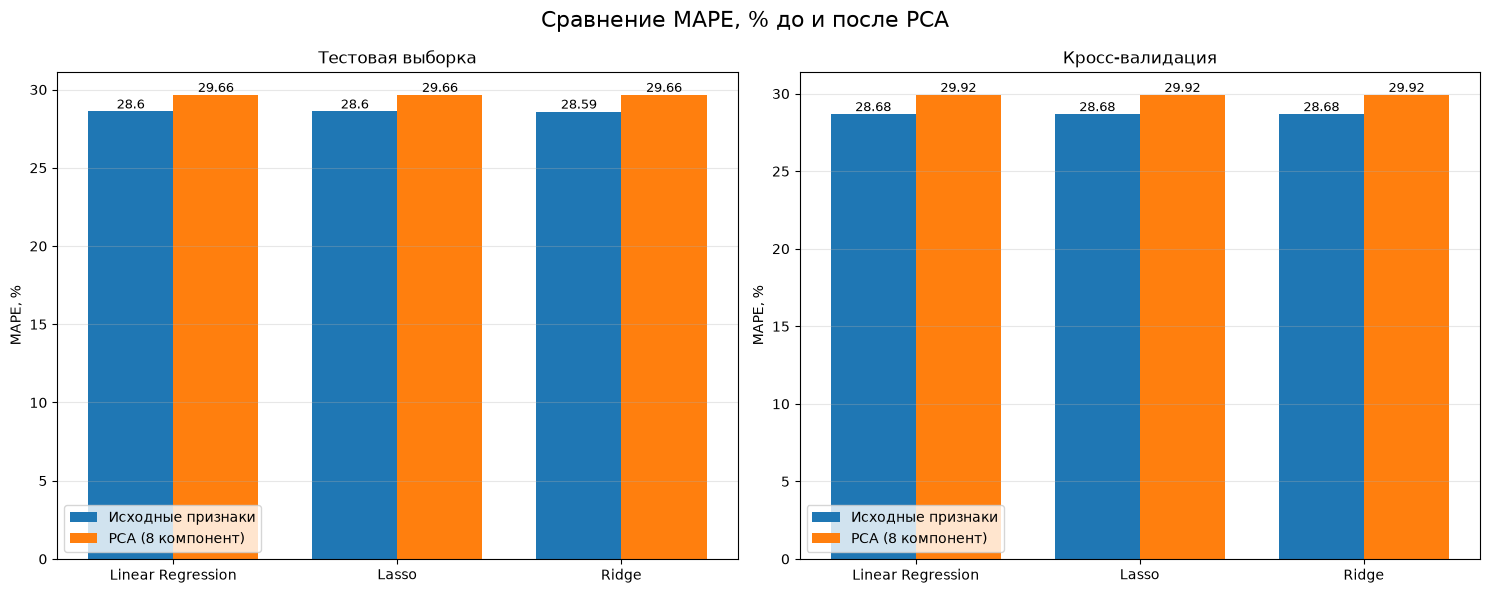

In [154]:
Plot_Comparison('MAPE (%)', 'MAPE, %')

MAPE после PCA вырос: на тесте с 28,60 до 29,66 %, по кросс-валидации с 28,68 до 29,92 %. Относительная ошибка прогноза увеличилась примерно на один процентный пункт. Изменение самое небольшое из трёх метрик, но по всем метрикам направление одно и то же: на сокращённом наборе компонент качество чуть хуже.

### Зависимость качества от числа компонент

                  RMSE     R2  MAPE (%)
Компонент                              
1         116,793.6312 0.0025   62.8582
2         116,494.1921 0.0076   62.4878
3          92,500.4129 0.3743   41.4126
4          79,287.4632 0.5403   30.8381
5          76,932.9153 0.5672   30.2232
6          76,292.5538 0.5744   30.2317
7          73,707.4344 0.6027   29.7326
8          73,732.6024 0.6025   29.6587
9          71,400.7554 0.6272   29.1633
10         70,011.0765 0.6416   28.3780
11         69,302.8989 0.6488   28.6070
12         69,297.7167 0.6488   28.5960


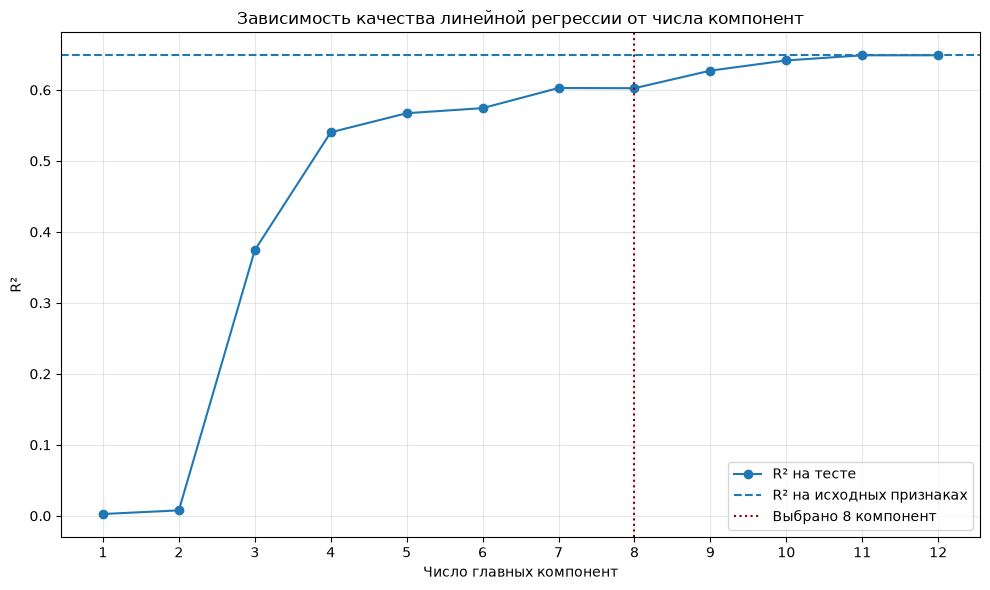

In [155]:
sweep_results = []

for k in range(1, n_total + 1):

    sweep_model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k, random_state=42)),
        ('model', LinearRegression())
    ])

    sweep_model.fit(X_train, y_train)
    y_pred = sweep_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    sweep_results.append({'Компонент': k, 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape})

sweep_results = pd.DataFrame(sweep_results).set_index('Компонент')
print(sweep_results.to_string(float_format=lambda v: f'{v:,.4f}'))

plt.figure(figsize=(10, 6))
plt.plot(sweep_results.index, sweep_results['R2'], 'o-', label='R² на тесте')
plt.axhline(before_pca.loc["Linear Regression", "Test R2"], linestyle="--", label="R² на исходных признаках")
plt.axvline(N_COMPONENTS, color='darkred', linestyle=':', label=f'Выбрано {N_COMPONENTS} компонент')
plt.xlabel('Число главных компонент')
plt.ylabel('R²')
plt.xticks(sweep_results.index)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.title('Зависимость качества линейной регрессии от числа компонент')
plt.tight_layout()

На графике по горизонтали - число компонент, по вертикали - R² на тесте, пунктир - R² модели на исходных признаках, красная вертикаль - выбранные 8 компонент.

- При **12 компонентах** (все) качество в точности совпадает с регрессией на исходных признаках (R² = 0,6488, RMSE = 69 298$). Это ожидаемо: PCA без отбрасывания компонент - просто поворот осей. Он устраняет мультиколлинеарность, но не меняет предсказаний.
- Первые две компоненты (PC1 - размер района, PC2 - координаты) почти ничего не объясняют в цене (R² примерно 0,01), хотя содержат больше половины дисперсии признаков. С третьей и четвёртой компонентами R² резко растёт до 0,54 (там INLAND и median_income).
- Потеря качества при k = 8 вызвана отброшенными компонентами PC9–PC12: на них приходится лишь 2,1 % дисперсии признаков, однако R² вырастает с 0,603 до 0,649 при их добавлении. Особенно заметны вклады PC9 (+0,025) и PC10 (+0,014).
- Причина в том, что PCA упорядочивает компоненты по дисперсии *признаков*, а не по связи с *ценой*. Малодисперсные направления (разности между сильно коррелированными признаками, например между числом спален и числом домохозяйств) оказываются информативны для цены.

Вывод: на 10-11 компонентах качество практически совпадает с исходным, а мультиколлинеарность уже устранена.

### Корреляционная матрица после PCA


Максимальная корреляция между разными компонентами: 1.7e-15


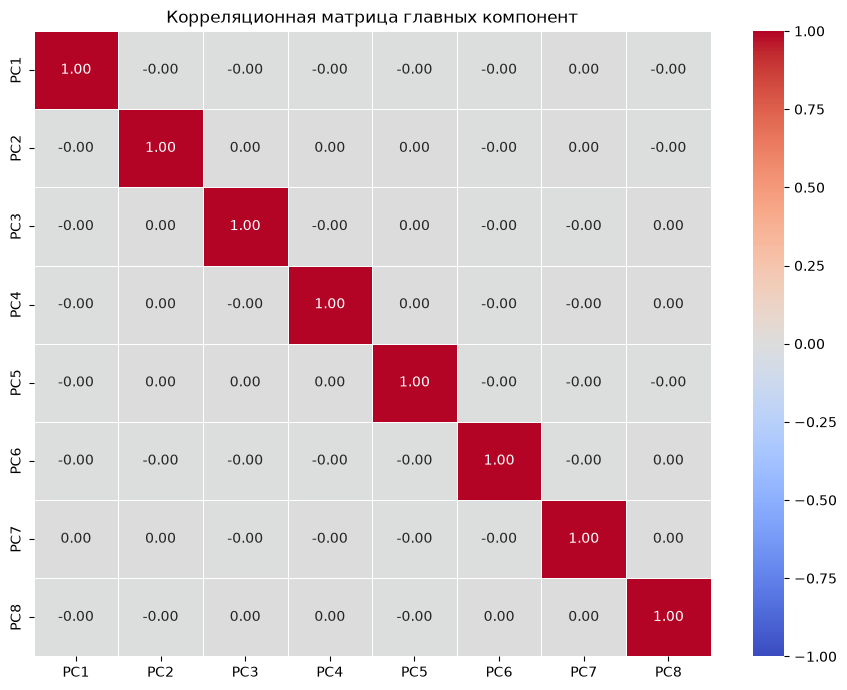

In [156]:
X_train_pca = pd.DataFrame(
    PCA(n_components=N_COMPONENTS, random_state=42).fit_transform(X_train_scaled),
    columns=[f'PC{i}' for i in range(1, N_COMPONENTS + 1)]
)

pca_corr = X_train_pca.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    pca_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Корреляционная матрица главных компонент')
plt.tight_layout()

X_pc_vif = X_train_pca.copy()
X_pc_vif.insert(0, 'const', 1.0)

print('\nМаксимальная корреляция между разными компонентами: {:.1e}'.format(
    np.abs(pca_corr.values - np.eye(N_COMPONENTS)).max()
))

Корреляционная матрица главных компонент - **единичная**: все внедиагональные элементы равны нулю с точностью до ошибки округления (максимальное значение 1.7e-15). Коэффициент VIF всех восьми компонент равен 1,00, тогда как у исходных признаков он достигал 36,3. Следовательно, мультиколлинеарность устранена полностью: главные компоненты ортогональны друг другу по построению.

# **Заключение**
В ходе анализа датасета California Housing Prices были построены модели линейной регрессии, Лассо и гребневой регрессии для прогнозирования median_house_value. Предварительная обработка данных включала удаление пропущенных значений в total_bedrooms (с 20640 до 20433 наблюдений) и кодирование категориального признака ocean_proximity в 12 признаков.

Корреляционный анализ выявил сильные зависимости между total_bedrooms, households, total_rooms, longitude и latitude, а также мультиколлинеарность, подтверждённую высокими значениями VIF для этих признаков. Исходные модели показали схожие результаты на тестовой выборке: R² приблезительно 0.649, RMSE примерно 69 298, MAPE примерно 28.6%. Кросс-валидация дала близкие значения.

Для устранения мультиколлинеарности был применён PCA, который сократил число признаков с 12 до 8, сохранив около 97.88% дисперсии. После PCA качество моделей ухудшилось: R² снизился до 0.6025, RMSE увеличился до 73 733, MAPE вырос до 29.66% на тестовой выборке. Результаты кросс-валидации также ухудшились.

Таким образом, PCA эффективно уменьшил размерность и устранил мультиколлинеарность, но не улучшил качество прогнозирования. Снижение качества связано с потерей полезной информации. Исходные модели на полном наборе признаков показывают более высокие результаты, а PCA полезен для уменьшения размерности.


# **Список источников**

1. Курс "Системы искусственного интеллекта и машинное обучение" // DiSpace НГТУ. URL: https://dispace.nstu.ru/course/965

2. California Housing Prices : набор данных // Kaggle. — URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices 



# **Приложение. Полный листинг программного кода**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

os.makedirs('graphs', exist_ok=True)

FILE_NAME = 'housing.csv'

encodings = [
    'utf-8',
    'utf-8-sig',
    'cp1251',
    'latin1'
]

df = None

for encoding in encodings:
    try:
        df = pd.read_csv(FILE_NAME, encoding=encoding)
        print(f'Файл успешно прочитан в кодировке: {encoding}')
        break

    except UnicodeDecodeError:
        continue

if df is None:
    print('Не удалось определить кодировку файла.')
    print('Попробуйте сохранить CSV в формате UTF-8.')
    exit()


print('=' * 60)
print('ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ')
print('=' * 60)

print('\nРазмер датасета:')
print(df.shape)

print('\nПервые 5 строк:')
print(df.head())

print('\nИнформация о датасете:')
df.info()

print('\nНазвания признаков:')
for i, column in enumerate(df.columns, 1):
    print(f'{i}. {column}')

print('\nПропущенные значения:')
print(df.isnull().sum())

print('\nКоличество дубликатов:')
print(df.duplicated().sum())

print('\nОписательная статистика:')
print(df.describe())

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print('=' * 60)
print('ОПРЕДЕЛЕНИЕ ТИПОВ ПРИЗНАКОВ')
print('=' * 60)

print('\nЧисловые признаки:')
for i, column in enumerate(numeric_columns, 1):
    print(f'{i}. {column}')

print('\nКатегориальные признаки:')
if categorical_columns:
    for i, column in enumerate(categorical_columns, 1):
        print(f'{i}. {column}')
else:
    print('Категориальных признаков нет.')


TARGET = 'median_house_value'

if TARGET not in df.columns:
    print(f'Ошибка: целевая переменная "{TARGET}" отсутствует в датасете.')
    exit()

numeric_features = [column for column in numeric_columns if column != TARGET]
categorical_features = categorical_columns.copy()


plt.figure(figsize=(10, 6))
sns.histplot(data=df, x=TARGET, bins=50, kde=True)
plt.title(f'Распределение целевой переменной: {TARGET}')
plt.xlabel(TARGET)
plt.ylabel('Количество объектов')
plt.grid(alpha=0.3)
plt.tight_layout()

columns_for_hist = numeric_features + [TARGET]

df[columns_for_hist].hist(
    figsize=(16, 12),
    bins=30,
    edgecolor='black'
)

plt.suptitle('Распределение числовых признаков', fontsize=16)
plt.tight_layout()


fig, axes = plt.subplots(
    1,
    len(columns_for_hist),
    figsize=(24, 6)
)

for ax, column in zip(axes, columns_for_hist):

    sns.boxplot(
        y=df[column],
        ax=ax
    )

    ax.set_title(column, fontsize=10)
    ax.set_ylabel('')

    ax.grid(alpha=0.3)

plt.suptitle(
    'Распределение числовых признаков и выбросы',
    fontsize=16
)

plt.tight_layout()


for i, column in enumerate(categorical_features, start=1):

    print('=' * 60)
    print(f'Распределение категориального признака: {column}')
    print('=' * 60)

    print(df[column].value_counts())

    if df[column].nunique() <= 20:
        plt.figure(figsize=(10, 6))
        sns.countplot(data=df, x=column)
        plt.title(f'Распределение объектов по признаку {column}')
        plt.xlabel(column)
        plt.ylabel('Количество объектов')
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        print(
            f'У признака {column} слишком много категорий '
            f'({df[column].nunique()}), график не строится.'
        )


for i, column in enumerate(numeric_features, start=1):

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x=column,
        y=TARGET,
        alpha=0.3
    )

    plt.title(f'Зависимость {TARGET} от {column}')
    plt.xlabel(column)
    plt.ylabel(TARGET)
    plt.grid(alpha=0.3)
    plt.tight_layout()


print('=' * 60)
print('ПРЕДОБРАБОТКА ДАННЫХ')
print('=' * 60)

print('\nПропущенные значения до обработки:')
print(df.isnull().sum())

rows_before = len(df)
df = df.dropna().copy()
rows_after = len(df)

print('\nУдаление пропущенных значений:')
print(f'Строк до обработки: {rows_before}')
print(f'Удалено строк: {rows_before - rows_after}')
print(f'Строк после обработки: {rows_after}')

print('\nПропущенные значения после обработки:')
print(df.isnull().sum().sum())


if categorical_features:

    print('\nКатегориальные признаки:')

    for column in categorical_features:
        print(f'{column}: {df[column].nunique()} категорий')

    df_encoded = pd.get_dummies(
        df,
        columns=categorical_features,
        drop_first=True,
        dtype=int
    )

else:
    print('\nКатегориальных признаков для кодирования нет.')
    df_encoded = df.copy()


print('\nРазмер данных после кодирования:')
print(df_encoded.shape)

print('\nСтолбцы после кодирования:')

for i, column in enumerate(df_encoded.columns, 1):
    print(f'{i}. {column}')

print('\nПервые 5 строк после предобработки:')
print(df_encoded.head())


df_encoded.to_csv(
    'preprocessed_data.csv',
    index=False
)


correlation_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Корреляционная матрица признаков')

plt.tight_layout()


X_vif = df_encoded.drop(columns=[TARGET]).astype(float)
X_vif.insert(0, 'const', 1.0)

vif_data = pd.DataFrame()
vif_data['Признак'] = X_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data = vif_data[vif_data['Признак'] != 'const'].reset_index(drop=True)


def vif_interpretation(value):
    if value < 5:
        return 'не выражена'
    elif value < 10:
        return 'возможна заметная'
    else:
        return 'высокая'


vif_data['Мультиколлинеарность'] = vif_data['VIF'].apply(vif_interpretation)
print('\nТаблица VIF (по убыванию):')
print(vif_data.sort_values('VIF', ascending=False).to_string(index=False))


print('\n' + "=" * 60)
print("РАЗДЕЛЕНИЕ НА ТРЕНИРОВОЧНУЮ И ТЕСТОВУЮ ВЫБОРКИ")
print("=" * 60)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

print("Целевая переменная: " + TARGET)

print("Количество признаков:", X.shape[1])
print("Количество наблюдений:", X.shape[0])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('\n' + "Разделение данных:")
print("Тренировочная выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

print('\n' + "Среднее значение целевой переменной:")
print(f'train: {y_train.mean():.0f}')
print(f'test:  {y_test.mean():.0f}')


models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
}

results = []

for model_name, model in models.items():

    print("Модель:", model_name)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 4))
    print("MAPE:", round(mape, 2), "%")

    results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test R2": r2,
        "Test MAPE (%)": mape
    })
    print("-" * 30)


print("=" * 81)
print("КРОСС-ВАЛИДАЦИЯ")
print("=" * 81)

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():
    
    print("Модель:", model_name)

    y_cv_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv
    )

    cv_rmse = np.sqrt(mean_squared_error(y_train, y_cv_pred))
    cv_r2 = r2_score(y_train, y_cv_pred)

    cv_mape = mean_absolute_percentage_error(
        y_train,
        y_cv_pred
    ) * 100

    
    fold_r2 = cross_val_score(
        model, 
        X_train, 
        y_train, 
        cv=cv, 
        scoring='r2'
    )

    print("CV RMSE:", round(cv_rmse, 2))
    print("CV R²:", round(cv_r2, 4))
    print("CV MAPE:", round(cv_mape, 2), "%")
    print(f'R² по фолдам: {np.round(fold_r2, 4)}, среднее {fold_r2.mean():.4f} ± {fold_r2.std():.4f}')
    print("-" * 81)

    cv_results.append({
        "Model": model_name,
        "CV RMSE": cv_rmse,
        "CV R2": cv_r2,
        "CV MAPE (%)": cv_mape
    })
    

results_df = pd.DataFrame(results)
cv_results_df = pd.DataFrame(cv_results)
final_results = results_df.merge(
    cv_results_df,
    on="Model"
)
print("=" * 81)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 81)

print(
    final_results.round(4).to_string(index=False)
)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model_name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)

    ax.scatter(y_test, y_pred, alpha=0.3, s=10)

    min_value = min(y_test.min(), y_pred.min())
    max_value = max(y_test.max(), y_pred.max())
    ax.plot([min_value, max_value], [min_value, max_value], 'r--')

    ax.set_xlabel('Фактическое значение')
    ax.set_ylabel('Предсказанное значение')
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

plt.suptitle('Фактические и предсказанные значения (тестовая выборка)', fontsize=16)
plt.tight_layout()


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

bp_results = []

for ax, (model_name, model) in zip(axes, models.items()):

    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    ax.scatter(y_pred, residuals, alpha=0.3, s=10)
    ax.axhline(y=0, color='r', linestyle='--')
    ax.set_xlabel('Предсказанное значение')
    ax.set_ylabel('Остаток')
    ax.set_title(model_name)
    ax.grid(alpha=0.3)

    lm_statistic, lm_pvalue, _, _ = het_breuschpagan(residuals, sm.add_constant(X_test))

    bp_results.append({
        'Model': model_name,
        'Среднее остатков': residuals.mean(),
        'Std остатков': residuals.std(),
        'Breusch-Pagan LM': lm_statistic,
        'p-value': lm_pvalue
    })

plt.suptitle('Графики остатков (тестовая выборка)', fontsize=16)
plt.tight_layout()

print('Анализ остатков и тест Бройша-Пагана:')
print(pd.DataFrame(bp_results).to_string(index=False, float_format=lambda v: f'{v:,.4f}'))

y_pred = models['Linear Regression'].predict(X_test)
residual_df = pd.DataFrame({'pred': y_pred, 'resid': y_test - y_pred})
residual_df['Группа'] = pd.qcut(
    residual_df['pred'], 4,
    labels=['1 (низкие)', '2', '3', '4 (высокие)']
)

print('\nОстатки по квартилям предсказанных значений (Linear Regression):')
print(
    residual_df.groupby('Группа', observed=True)['resid']
    .agg(['count', 'mean', 'std'])
    .to_string(float_format=lambda v: f'{v:,.0f}')
)


print('=' * 60)
print('МЕТОД ГЛАВНЫХ КОМПОНЕНТ (PCA)')
print('=' * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

n_total = len(pca_full.explained_variance_ratio_)

pca_table = pd.DataFrame({
    'Компонента': [f'PC{i}' for i in range(1, n_total + 1)],
    'Собственное значение': pca_full.explained_variance_,
    'Доля дисперсии': pca_full.explained_variance_ratio_,
    'Накопленная доля': np.cumsum(pca_full.explained_variance_ratio_)
})

print(pca_table.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

N_COMPONENTS = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1)
n_kaiser = int((pca_full.explained_variance_ > 1).sum())

print('\nКомпонент для сохранения 95% дисперсии:', N_COMPONENTS)
print('Компонент по критерию Кайзера (собственное значение > 1):', n_kaiser)


ratios = pca_full.explained_variance_ratio_
cumulative = np.cumsum(ratios)

n_total = len(ratios)
x_axis = np.arange(1, n_total + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(
    x_axis,
    ratios,
    marker="o"
)

axes[0].set_xlabel("Номер главной компоненты")
axes[0].set_ylabel("Доля объяснённой дисперсии")
axes[0].set_title("График каменистой осыпи (Scree Plot)")
axes[0].set_xticks(x_axis)
axes[0].grid(alpha=0.3)

axes[1].plot(
    x_axis,
    cumulative,
    marker="o"
)

axes[1].axhline(
    0.95,
    linestyle="--",
    label="95%"
)

axes[1].set_xlabel("Количество главных компонент")
axes[1].set_ylabel("Накопленная доля объяснённой дисперсии")
axes[1].set_title("Накопленная объяснённая дисперсия PCA")
axes[1].set_xticks(x_axis)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()


pca_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS)),
        ("model", LinearRegression())
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS)),
        ("model", Lasso(alpha=0.1, max_iter=10000))
    ]),
    
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=N_COMPONENTS)),
        ("model", Ridge(alpha=1.0))
    ])
}

pca_test_results = []
pca_cv_results = []

for model_name, model in pca_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    print(f"{model_name} - тест:")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    
    pca_test_results.append({
        "Model": model_name,
        "Test RMSE": rmse,
        "Test R2": r2,
        "Test MAPE (%)": mape
    })
    
    y_cv_pred = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv
    )
    
    rmse_cv = np.sqrt(mean_squared_error(y_train, y_cv_pred))
    r2_cv = r2_score(y_train, y_cv_pred)
    mape_cv = mean_absolute_percentage_error(y_train, y_cv_pred) * 100
    
    print(f"Кросс-валидация:")
    print(f"RMSE: {rmse_cv:.2f}")
    print(f"R²: {r2_cv:.4f}")
    print(f"MAPE: {mape_cv:.2f}%")
    print()
    
    pca_cv_results.append({
        "Model": model_name,
        "CV RMSE": rmse_cv,
        "CV R2": r2_cv,
        "CV MAPE (%)": mape_cv
    })

after_pca = (
    pd.DataFrame(pca_test_results)
    .set_index("Model")
    .join(
        pd.DataFrame(pca_cv_results).set_index("Model")
    )
)


before_pca = pd.DataFrame({
    "Test RMSE": [69297.72, 69297.72, 69297.75],
    "Test R2": [0.6488, 0.6488, 0.6488],
    "Test MAPE (%)": [28.60, 28.60, 28.59],
    "CV RMSE": [68729.51, 68729.50, 68729.00],
    "CV R2": [0.6431, 0.6431, 0.6431],
    "CV MAPE (%)": [28.68, 28.68, 28.68]
}, index=["Linear Regression", "Lasso", "Ridge"])

after_pca = pd.DataFrame({
    "Test RMSE": [73732.60, 73732.59, 73732.57],
    "Test R2": [0.6025, 0.6025, 0.6025],
    "Test MAPE (%)": [29.66, 29.66, 29.66],
    "CV RMSE": [72638.46, 72638.46, 72638.45],
    "CV R2": [0.6014, 0.6014, 0.6014],
    "CV MAPE (%)": [29.92, 29.92, 29.92]
}, index=["Linear Regression", "Lasso", "Ridge"])

print("ДО PCA:")
print(before_pca.round(4))

print(f"\nПОСЛЕ PCA ({N_COMPONENTS} компонент):")
print(after_pca.round(4))

print("\nИзменение (после − до):")
print((after_pca - before_pca).round(4))

print("\nИзменение, %:")
print(((after_pca / before_pca - 1) * 100).round(2))

comparison_df = pd.concat(
    [before_pca.add_prefix("До PCA "),
     after_pca.add_prefix("После PCA ")],
    axis=1
)


def Plot_Comparison(metric, ylabel):

    labels = list(before_pca.index)
    pos = np.arange(len(labels))
    width = 0.38

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, prefix, title in zip(axes, ['Test', 'CV'], ['Тестовая выборка', 'Кросс-валидация']):

        bars_before = ax.bar(pos - width / 2, before_pca[f'{prefix} {metric}'], width, label='Исходные признаки')
        bars_after = ax.bar(pos + width / 2, after_pca[f'{prefix} {metric}'], width, label=f'PCA ({N_COMPONENTS} компонент)')

        ax.bar_label(bars_before, fmt='%.4g', fontsize=9)
        ax.bar_label(bars_after, fmt='%.4g', fontsize=9)

        ax.set_xticks(pos)
        ax.set_xticklabels(labels)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.grid(axis='y', alpha=0.3)
        ax.legend()

    plt.suptitle(f'Сравнение {ylabel} до и после PCA', fontsize=16)
    plt.tight_layout()


Plot_Comparison('RMSE', 'RMSE')
Plot_Comparison('R2', 'R²')
Plot_Comparison('MAPE (%)', 'MAPE, %')

sweep_results = []

for k in range(1, n_total + 1):

    sweep_model = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k, random_state=42)),
        ('model', LinearRegression())
    ])

    sweep_model.fit(X_train, y_train)
    y_pred = sweep_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    sweep_results.append({'Компонент': k, 'RMSE': rmse, 'R2': r2, 'MAPE (%)': mape})

sweep_results = pd.DataFrame(sweep_results).set_index('Компонент')
print(sweep_results.to_string(float_format=lambda v: f'{v:,.4f}'))

plt.figure(figsize=(10, 6))
plt.plot(sweep_results.index, sweep_results['R2'], 'o-', label='R² на тесте')
plt.axhline(before_pca.loc["Linear Regression", "Test R2"], linestyle="--", label="R² на исходных признаках")
plt.axvline(N_COMPONENTS, color='darkred', linestyle=':', label=f'Выбрано {N_COMPONENTS} компонент')
plt.xlabel('Число главных компонент')
plt.ylabel('R²')
plt.xticks(sweep_results.index)
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.title('Зависимость качества линейной регрессии от числа компонент')
plt.tight_layout()

X_train_pca = pd.DataFrame(
    PCA(n_components=N_COMPONENTS, random_state=42).fit_transform(X_train_scaled),
    columns=[f'PC{i}' for i in range(1, N_COMPONENTS + 1)]
)

pca_corr = X_train_pca.corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    pca_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title('Корреляционная матрица главных компонент')
plt.tight_layout()

X_pc_vif = X_train_pca.copy()
X_pc_vif.insert(0, 'const', 1.0)

print('\nМаксимальная корреляция между разными компонентами: {:.1e}'.format(
    np.abs(pca_corr.values - np.eye(N_COMPONENTS)).max()
))